In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ast
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

RUTA = r'C:\Users\jezab\OneDrive\Escritorio\Adalab\Proyectos\proyectos_grupales\proyecto-da-promo-69-modulo-4.2-team-2\Datasets'

# Kaggle
tmdb_movies   = pd.read_csv(os.path.join(RUTA, 'tmdb_5000_movies.csv'))
tmdb_credits  = pd.read_csv(os.path.join(RUTA, 'tmdb_5000_credits.csv'))
tmdb_extra    = pd.read_csv(os.path.join(RUTA, 'moviesTMBD.csv'))
box_office    = pd.read_csv(os.path.join(RUTA, 'enhanced_box_office_data(2000-2024)u.csv'))
imdb_top      = pd.read_csv(os.path.join(RUTA, 'imdb_top_movies_1980_2026.csv'))

# IMDb oficial
basics        = pd.read_csv(os.path.join(RUTA, 'title.basics.tsv'),     sep='\t', on_bad_lines='skip', low_memory=False)
ratings       = pd.read_csv(os.path.join(RUTA, 'title.ratings.tsv'),    sep='\t', on_bad_lines='skip', low_memory=False)
crew          = pd.read_csv(os.path.join(RUTA, 'title.crew.tsv'),        sep='\t', on_bad_lines='skip', low_memory=False)
principals = pd.read_csv(os.path.join(RUTA, 'title.principals.tsv'), sep='\t', on_bad_lines='skip', low_memory=False, nrows=500000)
names         = pd.read_csv(os.path.join(RUTA, 'name.basics.tsv'),      sep='\t', on_bad_lines='skip', low_memory=False)

print('✅ Todos los archivos cargados')

✅ Todos los archivos cargados


In [3]:
for nombre, df in {
    'tmdb_movies':  tmdb_movies,
    'tmdb_credits': tmdb_credits,
    'tmdb_extra':   tmdb_extra,
    'box_office':   box_office,
    'imdb_top':     imdb_top,
    'basics':       basics,
    'ratings':      ratings,
    'crew':         crew,
    'principals':   principals,
    'names':        names,
}.items():
    print(f'\n{"="*55}')
    print(f'📄 {nombre}')
    print(f'{"="*55}')
    df.info()


📄 tmdb_movies
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status           

## 🎬 Filtrado de basics — Solo películas

El archivo `title.basics.tsv` contiene todo tipo de títulos: series, episodios, cortos, videojuegos, etc.
Filtramos únicamente por `titleType == 'movie'` para quedarnos solo con películas.

In [4]:
basics_movies = basics[basics['titleType'] == 'movie'].copy()
print(f'Total películas: {len(basics_movies)}')
print(f'(De {len(basics):,} filas originales)')

Total películas: 750061
(De 12,592,453 filas originales)


### 📌 Conclusiones
- De 12,5 millones de títulos, **750.061 son películas** (solo el 6% del total).
- El 94% restante son series, episodios, cortos y otros formatos que no necesitamos.
- Con 750k películas seguimos teniendo un dataset muy rico para nuestro análisis.

## 🔍 Nulos y valores \N en basics_movies

IMDb usa `\N` como valor nulo en lugar de dejarlo vacío.
Vamos a detectar cuántos hay en cada columna para decidir qué hacer con ellos.

In [5]:
# Reemplazamos \N por NaN real
basics_movies.replace('\\N', pd.NA, inplace=True)

# Contamos nulos
nulos = basics_movies.isnull().sum()
pct   = (nulos / len(basics_movies) * 100).round(2)

pd.DataFrame({'nulos': nulos, '%': pct})

,nulos,%
tconst,0,0.00
titleType,0,0.00
primaryTitle,3,0.00
originalTitle,3,0.00
isAdult,0,0.00
startYear,112877,15.05
endYear,750061,100.00
runtimeMinutes,277132,36.95
genres,77924,10.39


### 📌 Conclusiones
- `endYear` tiene el 100% de nulos — tiene sentido, esa columna es solo para series. La eliminaremos.
- `runtimeMinutes` tiene un 37% de nulos — muchas películas no tienen duración registrada. La conservamos pero con cautela.
- `startYear` tiene un 15% de nulos — son películas sin año registrado. Las eliminaremos en la limpieza.
- `genres` tiene un 10% de nulos — sin género no podemos clasificar la película. Las eliminaremos.
- `primaryTitle` y `originalTitle` tienen solo 3 nulos — inapreciable, las eliminaremos directamente.

## 🧹 Limpieza de basics_movies — Eliminación de columnas y filas con nulos críticos

Eliminamos `endYear` porque es irrelevante para películas.
Eliminamos filas sin `startYear`, `genres` o `primaryTitle` ya que son datos clave para nuestro análisis.

In [6]:
# Eliminamos columna irrelevante
basics_movies.drop(columns=['endYear', 'titleType'], inplace=True)

# Eliminamos filas con nulos críticos
basics_movies.dropna(subset=['startYear', 'genres', 'primaryTitle'], inplace=True)

# Resultado
print(f'Filas tras limpieza: {len(basics_movies):,}')
print(f'Columnas restantes: {list(basics_movies.columns)}')

Filas tras limpieza: 566,335
Columnas restantes: ['tconst', 'primaryTitle', 'originalTitle', 'isAdult', 'startYear', 'runtimeMinutes', 'genres']


### 📌 Conclusiones
- Pasamos de 750.061 a **566.335 películas** tras la limpieza — perdemos un 24% pero ganamos calidad.
- Eliminamos `endYear` y `titleType` por ser irrelevantes para películas.
- Las 7 columnas restantes son todas útiles para nuestro análisis.

## 🔧 Corrección de tipos de datos en basics_movies

`startYear` y `runtimeMinutes` se cargaron como `str` y necesitamos convertirlos a `int` para poder operar con ellos.

In [7]:
basics_movies['startYear']      = pd.to_numeric(basics_movies['startYear'],      errors='coerce').astype('Int64')
basics_movies['runtimeMinutes'] = pd.to_numeric(basics_movies['runtimeMinutes'], errors='coerce').astype('Int64')

basics_movies.dtypes

tconst              str
primaryTitle        str
originalTitle       str
isAdult           int64
startYear         Int64
runtimeMinutes    Int64
genres              str
dtype: object

### 📌 Conclusiones
- `startYear` y `runtimeMinutes` convertidos correctamente a `Int64`.
- `Int64` (con mayúscula) en lugar de `int64` porque admite nulos — importante ya que `runtimeMinutes` tiene un 37% de nulos.
- El resto de columnas tienen el tipo correcto.
- `basics_movies` está listo para cruzar con el resto de datasets.

## 📅 Exploración de startYear en basics_movies

Revisamos el rango de años para detectar valores fuera de lo esperado — películas con años muy antiguos, futuros o incorrectos.

In [8]:
print(basics_movies['startYear'].describe())
print(f'\nAños únicos fuera de rango (antes de 1880 o después de 2025):')
print(basics_movies[~basics_movies['startYear'].between(1880, 2025)]['startYear'].value_counts())

count       566335.0
mean     1997.723047
std        28.399252
min           1894.0
25%           1983.0
50%           2010.0
75%           2019.0
max           2032.0
Name: startYear, dtype: Float64

Años únicos fuera de rango (antes de 1880 o después de 2025):
startYear
2026    9446
2027     496
2028      57
2029      10
2030       2
2031       2
2032       1
Name: count, dtype: Int64


### 📌 Conclusiones
- El rango general tiene sentido: desde 1894 hasta 2032.
- Hay **10.014 películas con año futuro** (2026-2032) — son estrenos anunciados pero no estrenados aún.
- Las eliminaremos en el siguiente bloque para quedarnos solo con películas ya estrenadas.
- La mediana es 2010, lo que indica que la mitad del dataset son películas relativamente recientes.

## 📅 Filtrado por rango de años — 1980 a 2026

Nos quedamos solo con películas estrenadas entre 1980 y 2025.
1980 marca el inicio de la era moderna del cine friki (Star Wars, E.T., Alien...).

In [9]:
basics_movies = basics_movies[basics_movies['startYear'].between(1980, 2026)].copy()

print(f'Películas entre 1980 y 2026: {len(basics_movies):,}')
print(f'Año mínimo: {basics_movies["startYear"].min()}')
print(f'Año máximo: {basics_movies["startYear"].max()}')

Películas entre 1980 y 2026: 435,836
Año mínimo: 1980
Año máximo: 2026


### 📌 Conclusiones
- Nos quedamos con **435.836 películas** entre 1980 y 2026.
- Eliminamos todo lo anterior a 1980 y posterior a 2026.
- El dataset queda acotado a la era moderna del cine, que es la relevante para nuestro proyecto friki.

## 🎭 Exploración de géneros en basics_movies

La columna `genres` contiene hasta 3 géneros por película separados por comas.
Vamos a ver qué géneros existen y cuáles son los más frecuentes.

In [10]:
# Separamos los géneros y los contamos individualmente
todos_generos = basics_movies['genres'].str.split(',').explode()

print(f'Géneros únicos: {todos_generos.nunique()}')
print(f'\nTop 20 géneros más frecuentes:')
print(todos_generos.value_counts().head(20))

Géneros únicos: 26

Top 20 géneros más frecuentes:
genres
Drama          163914
Documentary    128484
Comedy          78902
Action          38285
Thriller        33878
Romance         32628
Horror          30644
Crime           25040
Adventure       17395
Biography       15260
Family          14297
Mystery         13701
Music           12788
History         11830
Fantasy         11616
Sci-Fi           9384
Animation        8604
Sport            6981
Adult            6224
War              4858
Name: count, dtype: int64


### 📌 Conclusiones
- Hay **26 géneros únicos** en el dataset.
- Los géneros más frecuentes son Drama, Documentary y Comedy — géneros generalistas.
- Nuestros géneros frikis de interés tienen buena representación:
    - Horror: 30.644 películas
    - Action: 38.285 películas
    - Sci-Fi: 9.384 películas
    - Fantasy: 11.616 películas
    - Animation: 8.604 películas
- `Adult` aparece con 6.224 entradas — lo filtraremos más adelante.
- Una película puede tener hasta 3 géneros, por eso el total supera las 435.836 filas.

## 🚀 Filtrado por géneros frikis de interés

Nos quedamos solo con las películas que pertenecen a nuestros géneros de interés:
Sci-Fi, Fantasy, Horror, Action, Animation y Adventure.
Además eliminamos el contenido para adultos.

In [11]:
GENEROS_FRIKI = ['Sci-Fi', 'Fantasy', 'Horror', 'Action', 'Animation', 'Adventure']

# Eliminamos contenido adulto
basics_movies = basics_movies[basics_movies['isAdult'] == 0].copy()

# Filtramos por géneros de interés (la película debe tener AL MENOS uno)
mask = basics_movies['genres'].str.contains('|'.join(GENEROS_FRIKI), na=False)
basics_friki = basics_movies[mask].copy()

print(f'Películas frikis: {len(basics_friki):,}')
print(f'(De {len(basics_movies):,} películas totales)')

Películas frikis: 94,896
(De 429,604 películas totales)


### 📌 Conclusiones
- Eliminamos 6.232 películas de contenido adulto.
- Nos quedamos con **94.896 películas frikis** — el 22% del total.
- Es un dataset muy rico y manejable para trabajar en Power BI.
- Una película puede aparecer en varios géneros a la vez (ej: Sci-Fi + Action).

## ⭐ Cruce de basics_friki con ratings

Añadimos el rating promedio y número de votos de IMDb a cada película.
El cruce se hace por la columna `tconst` que es el identificador único de IMDb.

In [12]:
basics_friki = basics_friki.merge(ratings, on='tconst', how='left')

print(f'Filas tras el cruce: {len(basics_friki):,}')
print(f'\nNulos en ratings:')
print(basics_friki[['averageRating', 'numVotes']].isnull().sum())

Filas tras el cruce: 94,896

Nulos en ratings:
averageRating    25929
numVotes         25929
dtype: int64


### 📌 Conclusiones
- El cruce se realizó correctamente, mantenemos las **94.896 películas**.
- **25.929 películas (27%) no tienen rating** — son películas que existen en IMDb pero no tienen votos suficientes para aparecer en ratings.
- Las conservamos de momento pero las tendremos en cuenta: para análisis de ratings trabajaremos solo con las que sí tienen valoración.

## 🗳️ Filtrado por mínimo de votos

Las películas con muy pocos votos tienen ratings poco representativos.
Establecemos un mínimo de 100 votos para considerar un rating fiable.

In [13]:
basics_friki_rated = basics_friki[basics_friki['numVotes'] >= 100].copy()

print(f'Películas con más de 100 votos: {len(basics_friki_rated):,}')
print(f'Películas descartadas: {len(basics_friki) - len(basics_friki_rated):,}')
print(f'\nEstadísticas de votos:')
print(basics_friki_rated['numVotes'].describe())

Películas con más de 100 votos: 38,531
Películas descartadas: 56,365

Estadísticas de votos:
count    3.853100e+04
mean     1.739685e+04
std      8.346423e+04
min      1.000000e+02
25%      2.460000e+02
50%      7.070000e+02
75%      3.227000e+03
max      2.827344e+06
Name: numVotes, dtype: float64


### 📌 Conclusiones
- Con mínimo 100 votos nos quedamos con **38.531 películas** — perdemos el 59% pero ganamos mucha calidad en los ratings.
- La media de votos es 17.396 pero la mediana es solo 707 — hay películas muy votadas que distorsionan la media (máximo 2,8 millones de votos).
- El 25% de las películas tiene menos de 246 votos — son películas poco conocidas pero con rating válido.
- Este será nuestro dataset principal para los análisis de valoraciones.

## 🎬 Añadir directores a basics_friki_rated

Cruzamos con `crew` para obtener el `nconst` del director y luego con `names` para obtener su nombre real.
Los directores en `crew` pueden venir varios separados por comas — nos quedamos solo con el primero.

In [14]:
# Nos quedamos solo con el primer director
crew['director_id'] = crew['directors'].str.split(',').str[0]

# Cruce con basics_friki_rated
basics_friki_rated = basics_friki_rated.merge(
    crew[['tconst', 'director_id']], on='tconst', how='left'
)

# Cruce con names para obtener el nombre
basics_friki_rated = basics_friki_rated.merge(
    names[['nconst', 'primaryName']].rename(columns={'primaryName': 'director_name'}),
    left_on='director_id', right_on='nconst', how='left'
)

# Limpiamos columnas innecesarias
basics_friki_rated.drop(columns=['director_id', 'nconst'], inplace=True)

print(f'Filas: {len(basics_friki_rated):,}')
print(f'Nulos en director_name: {basics_friki_rated["director_name"].isnull().sum():,}')
print(basics_friki_rated[['tconst', 'primaryTitle', 'director_name']].head(5))

Filas: 38,531
Nulos en director_name: 72
      tconst     primaryTitle      director_name
0  tt0035423   Kate & Leopold      James Mangold
1  tt0066020      Lucky Seven      Chen-Kuo Chao
2  tt0066151  Ninja Destroyer         Godfrey Ho
3  tt0067100      Firecracker  Cirio H. Santiago
4  tt0071560        Evil Town      Curtis Hanson


### 📌 Conclusiones
- El cruce se realizó correctamente, mantenemos las **38.531 películas**.
- Solo **72 películas sin director** (0.2%) — inapreciable, las conservamos.
- Cuando hay varios directores nos quedamos con el primero — suficiente para nuestro análisis.
- El dataset ya tiene: título, año, géneros, duración, rating, votos y director. ✅

## 📊 Exploración final de basics_friki_rated

Vistazo general al dataset limpio de IMDb antes de pasar a los archivos de Kaggle.

In [15]:
print(f'Shape: {basics_friki_rated.shape}')
print(f'\nColumnas y tipos:')
print(basics_friki_rated.dtypes)
print(f'\nEstadísticas generales:')
print(basics_friki_rated.describe())
print(f'\nPrimeras 5 filas:')
display(basics_friki_rated.head())

Shape: (38531, 10)

Columnas y tipos:
tconst                str
primaryTitle          str
originalTitle         str
isAdult             int64
startYear           Int64
runtimeMinutes      Int64
genres                str
averageRating     float64
numVotes          float64
director_name         str
dtype: object

Estadísticas generales:
       isAdult    startYear  runtimeMinutes  averageRating      numVotes
count  38531.0      38531.0         37994.0   38531.000000  3.853100e+04
mean       0.0  2009.810568      100.101253       5.255477  1.739685e+04
std        0.0    12.293128       23.326013       1.408751  8.346423e+04
min        0.0       1980.0            26.0       1.000000  1.000000e+02
25%        0.0       2002.0            87.0       4.300000  2.460000e+02
50%        0.0       2013.0            95.0       5.300000  7.070000e+02
75%        0.0       2020.0           108.0       6.300000  3.227000e+03
max        0.0       2026.0           808.0       9.900000  2.827344e+06

Prime

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,director_name
0,tt0035423,Kate & Leopold,Kate & Leopold,0,2001,118,"Comedy,Fantasy,Romance",6.4,94104.0,James Mangold
1,tt0066020,Lucky Seven,7 xiao fu,0,1986,80,"Action,Comedy",6.8,358.0,Chen-Kuo Chao
2,tt0066151,Ninja Destroyer,Ninja Destroyer,0,1986,92,"Action,Adventure",3.7,126.0,Godfrey Ho
3,tt0067100,Firecracker,Firecracker,0,1981,77,"Action,Drama,Thriller",5.6,1082.0,Cirio H. Santiago
4,tt0071560,Evil Town,Evil Town,0,1985,82,Horror,3.8,503.0,Curtis Hanson


### 📌 Conclusiones
- Dataset limpio con **38.531 películas y 10 columnas** listas para usar.
- `isAdult` es siempre 0 — la podemos eliminar, no aporta información.
- Rating medio de 5.25 sobre 10 — distribución bastante centrada.
- Duración media de 100 minutos, con un máximo de 808 — ese valor es sospechoso, lo revisaremos.
- `runtimeMinutes` tiene 537 nulos (38.531 - 37.994) — asumible.
- El dataset cubre desde 1980 hasta 2026 correctamente. ✅

In [16]:
basics_friki_rated.drop(columns=['isAdult'], inplace=True)

In [17]:
basics_friki_rated[basics_friki_rated['runtimeMinutes'] == 808][['primaryTitle', 'startYear', 'runtimeMinutes']]

,primaryTitle,startYear,runtimeMinutes
37827,La Flor,2018,808


## 🎬 Exploración de tmdb_movies

Analizamos el dataset de TMDB con 4.803 películas.
Contiene presupuesto, recaudación, países de producción, géneros y valoraciones.

In [18]:
print(f'Shape: {tmdb_movies.shape}')
print(f'\nNulos por columna:')
nulos = tmdb_movies.isnull().sum()
pct   = (nulos / len(tmdb_movies) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))
print(f'\nEstadísticas generales:')
print(tmdb_movies.describe())

Shape: (4803, 20)

Nulos por columna:
                      nulos      %
budget                    0   0.00
genres                    0   0.00
homepage               3091  64.36
id                        0   0.00
keywords                  0   0.00
original_language         0   0.00
original_title            0   0.00
overview                  3   0.06
popularity                0   0.00
production_companies      0   0.00
production_countries      0   0.00
release_date              1   0.02
revenue                   0   0.00
runtime                   2   0.04
spoken_languages          0   0.00
status                    0   0.00
tagline                 844  17.57
title                     0   0.00
vote_average              0   0.00
vote_count                0   0.00

Estadísticas generales:
             budget             id   popularity       revenue      runtime  \
count  4.803000e+03    4803.000000  4803.000000  4.803000e+03  4801.000000   
mean   2.904504e+07   57165.484281    21.49230

### 📌 Conclusiones
- `homepage` tiene un 64% de nulos — la eliminaremos, no es útil para el análisis.
- `tagline` tiene un 17% de nulos — la eliminaremos también.
- `budget` y `revenue` tienen mínimo 0 — hay muchas películas sin dato económico registrado, no son nulos reales sino ceros.
- Presupuesto medio de 29M$ y recaudación media de 82M$ — pero la mediana de revenue es 19M$, hay blockbusters que distorsionan la media.
- `runtime` tiene un mínimo de 0 — hay películas con duración 0, las filtraremos.
- `vote_average` tiene mínimo 0 — películas sin votos, las filtraremos.
- `genres`, `production_countries`, `production_companies` vienen en formato JSON — hay que parsearlos.

## 🧹 Limpieza de tmdb_movies

Eliminamos columnas innecesarias, filtramos filas con runtime y vote_average a 0
y parseamos las columnas en formato JSON.

In [19]:
# Eliminamos columnas innecesarias
tmdb_movies.drop(columns=['homepage', 'tagline', 'keywords', 'spoken_languages', 'status'], inplace=True)

# Filtramos runtime y vote_average a 0
tmdb_movies = tmdb_movies[tmdb_movies['runtime'] > 0].copy()
tmdb_movies = tmdb_movies[tmdb_movies['vote_average'] > 0].copy()

# Parseamos columnas JSON
def extraer_nombres(columna):
    try:
        return [d['name'] for d in ast.literal_eval(columna)]
    except:
        return []

tmdb_movies['genres']               = tmdb_movies['genres'].apply(extraer_nombres)
tmdb_movies['production_countries'] = tmdb_movies['production_countries'].apply(extraer_nombres)
tmdb_movies['production_companies'] = tmdb_movies['production_companies'].apply(extraer_nombres)

print(f'Shape tras limpieza: {tmdb_movies.shape}')
print(f'\nEjemplo géneros: {tmdb_movies["genres"].iloc[0]}')
print(f'Ejemplo países: {tmdb_movies["production_countries"].iloc[0]}')

Shape tras limpieza: (4716, 15)

Ejemplo géneros: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Ejemplo países: ['United States of America', 'United Kingdom']


### 📌 Conclusiones
- Pasamos de 4.803 a **4.716 películas** tras eliminar las filas con runtime y vote_average a 0.
- Las columnas JSON se parsearon correctamente — ahora `genres` y `production_countries` son listas de Python.
- Eliminamos 5 columnas irrelevantes para nuestro análisis.
- El dataset tiene 15 columnas limpias y listas para usar.
- El siguiente paso será explotar las listas de géneros y países para poder analizarlos en Power BI.

## 💰 Exploración de budget y revenue en tmdb_movies

Analizamos cuántas películas tienen presupuesto y recaudación registrados.
Los valores 0 indican dato no disponible, no que la película no tuviera presupuesto.

In [20]:
sin_budget  = (tmdb_movies['budget'] == 0).sum()
sin_revenue = (tmdb_movies['revenue'] == 0).sum()
con_ambos   = ((tmdb_movies['budget'] > 0) & (tmdb_movies['revenue'] > 0)).sum()

print(f'Películas sin presupuesto (0):  {sin_budget:,} ({sin_budget/len(tmdb_movies)*100:.1f}%)')
print(f'Películas sin recaudación (0):  {sin_revenue:,} ({sin_revenue/len(tmdb_movies)*100:.1f}%)')
print(f'Películas con ambos datos:      {con_ambos:,} ({con_ambos/len(tmdb_movies)*100:.1f}%)')

print(f'\nTop 5 películas más taquilleras:')
display(tmdb_movies[tmdb_movies['revenue'] > 0][['title', 'startYear' if 'startYear' in tmdb_movies.columns else 'release_date', 'budget', 'revenue']].sort_values('revenue', ascending=False).head())

Películas sin presupuesto (0):  964 (20.4%)
Películas sin recaudación (0):  1,343 (28.5%)
Películas con ambos datos:      3,227 (68.4%)

Top 5 películas más taquilleras:


,title,release_date,budget,revenue
0,Avatar,2009-12-10,237000000,2787965087
25,Titanic,1997-11-18,200000000,1845034188
16,The Avengers,2012-04-25,220000000,1519557910
28,Jurassic World,2015-06-09,150000000,1513528810
44,Furious 7,2015-04-01,190000000,1506249360


### 📌 Conclusiones
- El **68.4% de las películas tienen ambos datos económicos** — suficiente para el análisis de taquilla.
- Un 20% sin presupuesto y 28% sin recaudación — los trataremos como nulos en Power BI, no como ceros.
- El Top 5 taquillero tiene sentido: Avatar, Titanic, Avengers... todos géneros frikis. ✅
- Avatar lidera con 2.787M$ de recaudación con un presupuesto de 237M$ — multiplicó por 11 su inversión.
- En el siguiente paso reemplazaremos los 0 por NaN para no distorsionar los cálculos de medias.

## 🔧 Reemplazar ceros por NaN en budget y revenue

Los valores 0 en budget y revenue no son datos reales sino ausencia de dato.
Los reemplazamos por NaN para no distorsionar los cálculos estadísticos.

In [21]:
tmdb_movies['budget']  = tmdb_movies['budget'].replace(0, pd.NA)
tmdb_movies['revenue'] = tmdb_movies['revenue'].replace(0, pd.NA)

print(f'Nulos en budget:  {tmdb_movies["budget"].isnull().sum():,}')
print(f'Nulos en revenue: {tmdb_movies["revenue"].isnull().sum():,}')

Nulos en budget:  964
Nulos en revenue: 1,343


### 📌 Conclusiones
- Los 964 ceros de budget y 1.343 de revenue se convirtieron correctamente a NaN.
- Ahora las medias y estadísticas de presupuesto y recaudación serán representativas.
- `tmdb_movies` está prácticamente listo. ✅

## 💵 Exploración de box_office

Analizamos el dataset de taquilla mundial entre 2000 y 2024.
Contiene recaudación mundial, doméstica y extranjera de las 5.000 películas más taquilleras.

In [22]:
print(f'Shape: {box_office.shape}')
print(f'\nNulos por columna:')
nulos = box_office.isnull().sum()
pct   = (nulos / len(box_office) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))
print(f'\nEstadísticas generales:')
print(box_office.describe())
print(f'\nPrimeras 5 filas:')
display(box_office.head())

Shape: (5000, 13)

Nulos por columna:
                      nulos     %
Rank                      0  0.00
Release Group             0  0.00
$Worldwide                0  0.00
$Domestic                 0  0.00
Domestic %                0  0.00
$Foreign                  0  0.00
Foreign %                 0  0.00
Year                      0  0.00
Genres                  178  3.56
Rating                  170  3.40
Vote_Count              170  3.40
Original_Language       170  3.40
Production_Countries    200  4.00

Estadísticas generales:
             Rank    $Worldwide     $Domestic   Domestic %      $Foreign  \
count  5000.00000  5.000000e+03  5.000000e+03  5000.000000  5.000000e+03   
mean    100.50000  1.192137e+08  4.472523e+07    35.740620  7.448809e+07   
std      57.74008  2.005243e+08  7.727026e+07    30.656992  1.334932e+08   
min       1.00000  1.666028e+06  0.000000e+00     0.000000  0.000000e+00   
25%      50.75000  2.466220e+07  9.275150e+04     0.200000  1.371034e+07   
50%  

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


### 📌 Conclusiones
- Dataset muy limpio, nulos mínimos (máximo 4% en `Production_Countries`).
- `Rating` viene en formato string `"6.126/10"` — hay que parsearlo a float.
- `Genres` viene como string separado por comas — hay que parsearlo igual que en basics.
- Recaudación media mundial de 119M$ con máximo de 2.799M$ — son las 5.000 más taquilleras por año.
- El dataset cubre 2000-2024 con exactamente 200 películas por año (Rank 1-200).
- `Production_Countries` también viene como string separado por comas — hay que parsearlo.

## 🧹 Limpieza de box_office

Parseamos `Rating` a float, y `Genres` y `Production_Countries` a listas.
Renombramos columnas para que sean más manejables.

In [23]:
# Renombramos columnas
box_office.columns = ['rank', 'title', 'worldwide', 'domestic', 'domestic_pct', 
                      'foreign', 'foreign_pct', 'year', 'genres', 'rating', 
                      'vote_count', 'original_language', 'production_countries']

# Parseamos rating — quitamos "/10" y convertimos a float
box_office['rating'] = box_office['rating'].str.replace('/10', '', regex=False)
box_office['rating'] = pd.to_numeric(box_office['rating'], errors='coerce')

# Parseamos genres y production_countries a listas
box_office['genres']               = box_office['genres'].str.split(', ')
box_office['production_countries'] = box_office['production_countries'].str.split(', ')

print(f'Shape: {box_office.shape}')
print(f'\nEjemplo rating: {box_office["rating"].iloc[0]}')
print(f'Ejemplo géneros: {box_office["genres"].iloc[0]}')
print(f'Ejemplo países: {box_office["production_countries"].iloc[0]}')
print(f'\nEstadísticas rating:')
print(box_office['rating'].describe())

Shape: (5000, 13)

Ejemplo rating: 6.126
Ejemplo géneros: ['Adventure', 'Action', 'Thriller']
Ejemplo países: ['United States of America']

Estadísticas rating:
count    4830.000000
mean        6.510418
std         0.951805
min         0.000000
25%         6.011000
50%         6.600000
75%         7.107750
max         9.700000
Name: rating, dtype: float64


### 📌 Conclusiones
- `Rating` parseado correctamente a float — media de 6.51 sobre 10. ✅
- `Genres` y `Production_Countries` parseados correctamente a listas. ✅
- Rating mínimo de 0 — hay películas sin rating, las tendremos en cuenta.
- Las películas más taquilleras tienen un rating medio de 6.51, ligeramente superior al 5.25 de IMDb general — tiene sentido, las más vistas suelen estar mejor valoradas.

## ⭐ Exploración de imdb_top

Analizamos el dataset con las películas mejor valoradas de IMDb entre 1980 y 2026.
Contiene 16.252 películas con rating, votos, géneros y URL de IMDb.

In [24]:
print(f'Shape: {imdb_top.shape}')
print(f'\nNulos por columna:')
nulos = imdb_top.isnull().sum()
pct   = (nulos / len(imdb_top) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))
print(f'\nEstadísticas generales:')
print(imdb_top.describe())
print(f'\nPrimeras 5 filas:')
display(imdb_top.head())

Shape: (16252, 9)

Nulos por columna:
                 nulos     %
imdb_id              0  0.00
title                0  0.00
original_title       0  0.00
year                 0  0.00
runtime_minutes      1  0.01
genres               6  0.04
average_rating       0  0.00
num_votes            0  0.00
imdb_url             0  0.00

Estadísticas generales:
               year  runtime_minutes  average_rating     num_votes
count  16252.000000     16251.000000    16252.000000  1.625200e+04
mean    2008.790118       109.147376        6.395194  6.633172e+04
std       11.581006        22.110801        1.050908  1.557366e+05
min     1980.000000        43.000000        1.000000  5.000000e+03
25%     2001.000000        94.000000        5.800000  8.397500e+03
50%     2011.000000       104.000000        6.500000  1.726600e+04
75%     2018.000000       119.000000        7.100000  5.386725e+04
max     2026.000000       566.000000        9.300000  3.182733e+06

Primeras 5 filas:


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692


### 📌 Conclusiones
- Dataset muy limpio — prácticamente sin nulos (máximo 6 en géneros). ✅
- Tiene `imdb_id` — clave para cruzar con `basics_friki_rated`. ✅
- Rating medio de 6.39 con mínimo de 5.000 votos — son películas con cierta relevancia.
- Duración media de 109 minutos, máximo de 566 — revisaremos ese valor.
- El Top 5 son películas icónicas y bien conocidas — datos fiables. ✅
- `genres` viene separado por comas sin espacios — hay que parsearlo igual que los anteriores.
- Este dataset es muy valioso porque tiene el `imdb_id` que nos permite cruzar con todos los demás.

## 🧹 Limpieza de imdb_top

Parseamos `genres` a listas, eliminamos los nulos y revisamos el valor extremo de duración.

In [25]:
# Eliminamos nulos
imdb_top.dropna(subset=['genres', 'runtime_minutes'], inplace=True)

# Parseamos géneros a lista
imdb_top['genres'] = imdb_top['genres'].str.split(',')

# Revisamos la película de 566 minutos
print(imdb_top[imdb_top['runtime_minutes'] == imdb_top['runtime_minutes'].max()][['title', 'year', 'runtime_minutes']])

print(f'\nShape tras limpieza: {imdb_top.shape}')
print(f'\nEjemplo géneros: {imdb_top["genres"].iloc[0]}')

       title  year  runtime_minutes
10171  Shoah  1985            566.0

Shape tras limpieza: (16245, 9)

Ejemplo géneros: ['Drama']


### 📌 Conclusiones
- Solo eliminamos 7 filas con nulos — dataset prácticamente intacto con **16.245 películas**. ✅
- La película de 566 minutos es **Shoah (1985)**, un documental sobre el Holocausto. Es un dato real y correcto, la dejamos.
- `genres` parseado correctamente a listas. ✅
- `imdb_top` está listo para cruzar con el resto de datasets.

## 🎭 Exploración de tmdb_credits y tmdb_extra

Analizamos los dos datasets restantes de Kaggle.
`tmdb_credits` contiene el reparto y equipo técnico de cada película.
`tmdb_extra` es un dataset complementario de TMDB con 9.980 películas.

In [26]:
print('=== tmdb_credits ===')
print(f'Shape: {tmdb_credits.shape}')
nulos = tmdb_credits.isnull().sum()
pct   = (nulos / len(tmdb_credits) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))
display(tmdb_credits.head(3))

print('\n=== tmdb_extra ===')
print(f'Shape: {tmdb_extra.shape}')
nulos = tmdb_extra.isnull().sum()
pct   = (nulos / len(tmdb_extra) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))
display(tmdb_extra.head(3))

=== tmdb_credits ===
Shape: (4803, 4)
          nulos    %
movie_id      0  0.0
title         0  0.0
cast          0  0.0
crew          0  0.0


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."



=== tmdb_extra ===
Shape: (9980, 10)
                   nulos     %
Unnamed: 0             0  0.00
id                     0  0.00
title                  0  0.00
popularity             0  0.00
adult                  0  0.00
original_language      0  0.00
overview               2  0.02
release_date           2  0.02
vote_average           0  0.00
vote_count             0  0.00


,Unnamed: 0,id,title,popularity,adult,original_language,overview,release_date,vote_average,vote_count
0,0,1007757,Swapped,327.5134,False,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,1,278,The Shawshank Redemption,65.3308,False,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,2,238,The Godfather,47.2346,False,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929


### 📌 Conclusiones
- `tmdb_credits` está completamente limpio, sin nulos. ✅
- `cast` y `crew` vienen en formato JSON — los parsearemos cuando necesitemos actores o directores específicos.
- `tmdb_extra` tiene `Unnamed: 0` — lo eliminaremos, es un índice residual.
- `tmdb_extra` tiene 2 nulos en `overview` y `release_date` — inapreciable.
- `tmdb_extra` tiene columna `adult` — la revisaremos y filtraremos.
- Ambos datasets se cruzan con `tmdb_movies` por `id` / `movie_id`. ✅

## 🧹 Limpieza de tmdb_extra

Eliminamos la columna índice residual, filtramos contenido adulto y los nulos.

In [27]:
# Eliminamos columna índice residual
tmdb_extra.drop(columns=['Unnamed: 0'], inplace=True)

# Filtramos contenido adulto
tmdb_extra = tmdb_extra[tmdb_extra['adult'] == False].copy()

# Eliminamos columna adult — ya no aporta
tmdb_extra.drop(columns=['adult'], inplace=True)

# Eliminamos nulos
tmdb_extra.dropna(inplace=True)

print(f'Shape tras limpieza: {tmdb_extra.shape}')
print(f'Columnas: {list(tmdb_extra.columns)}')
display(tmdb_extra.head(3))

Shape tras limpieza: (9977, 8)
Columnas: ['id', 'title', 'popularity', 'original_language', 'overview', 'release_date', 'vote_average', 'vote_count']


,id,title,popularity,original_language,overview,release_date,vote_average,vote_count
0,1007757,Swapped,327.5134,en,"A small woodland creature and a majestic bird,...",2026-05-01,8.987,1320
1,278,The Shawshank Redemption,65.3308,en,Imprisoned in the 1940s for the double murder ...,1994-09-23,8.721,30387
2,238,The Godfather,47.2346,en,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,8.686,22929


### 📌 Conclusiones
- `tmdb_extra` limpio con **9.977 películas y 8 columnas**. ✅
- Eliminamos 3 filas — 1 adulto y 2 nulos.
- `release_date` viene como string — la convertiremos a datetime cuando la necesitemos.
- Este dataset aporta principalmente `popularity`, `overview` y `vote_average` actualizados.

## 🔗 Estrategia de cruces entre datasets

Antes de cruzar definimos la estrategia — qué dataset es la base y cómo se unen los demás.

In [28]:
# Miramos columnas de todos los datasets buscando IDs
print('=== tmdb_movies ===')
print(tmdb_movies.columns.tolist())
print(tmdb_movies[['id', 'title', 'release_date']].head(3))

print('\n=== tmdb_credits ===')
print(tmdb_credits.columns.tolist())
print(tmdb_credits.head(3))

print('\n=== tmdb_extra ===')
print(tmdb_extra.columns.tolist())
print(tmdb_extra[['id', 'title']].head(3))

print('\n=== imdb_top ===')
print(imdb_top.columns.tolist())
print(imdb_top[['imdb_id', 'title']].head(3))

print('\n=== box_office ===')
print(box_office.columns.tolist())
print(box_office[['title', 'year']].head(3))

=== tmdb_movies ===
['budget', 'genres', 'id', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'title', 'vote_average', 'vote_count']
       id                                     title release_date
0   19995                                    Avatar   2009-12-10
1     285  Pirates of the Caribbean: At World's End   2007-05-19
2  206647                                   Spectre   2015-10-26

=== tmdb_credits ===
['movie_id', 'title', 'cast', 'crew']
   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", 

## 🔗 Cruce 1 — basics_friki_rated + imdb_top

Cruzamos por `tconst` e `imdb_id` — ambos son identificadores oficiales de IMDb.
Es el cruce más fiable de todos.

In [29]:
df_main = basics_friki_rated.merge(
    imdb_top[['imdb_id', 'imdb_url']],
    left_on='tconst',
    right_on='imdb_id',
    how='left'
).drop(columns=['imdb_id'])

print(f'Shape tras cruce 1: {df_main.shape}')
print(f'Películas con imdb_url: {df_main["imdb_url"].notna().sum():,}')
print(f'Películas sin imdb_url: {df_main["imdb_url"].isna().sum():,}')

Shape tras cruce 1: (38531, 10)
Películas con imdb_url: 7,729
Películas sin imdb_url: 30,802


### 📌 Conclusiones
- Cruce realizado correctamente, mantenemos las **38.531 películas**. ✅
- Solo **7.729 películas (20%)** tienen `imdb_url` — tiene sentido porque `imdb_top` solo tiene las mejor valoradas, no todas.
- El 80% restante son películas válidas pero que no están en el top de IMDb.
- La URL es un dato complementario, no crítico — seguimos adelante.

## 🔗 Cruce 2 — df_main + tmdb_movies

Cruzamos por `original_title` y año para añadir budget, revenue y production_countries.
Extraemos el año de `release_date` de tmdb_movies para que coincida con `startYear`.

In [30]:
# Extraemos año de release_date
tmdb_movies['year'] = pd.to_datetime(tmdb_movies['release_date'], errors='coerce').dt.year.astype('Int64')

# Cruce por original_title + year
df_main = df_main.merge(
    tmdb_movies[['original_title', 'year', 'budget', 'revenue', 'production_countries', 'production_companies', 'popularity']],
    left_on=['originalTitle', 'startYear'],
    right_on=['original_title', 'year'],
    how='left'
).drop(columns=['original_title', 'year'])

print(f'Shape tras cruce 2: {df_main.shape}')
print(f'Películas con revenue: {df_main["revenue"].notna().sum():,}')
print(f'Películas con budget:  {df_main["budget"].notna().sum():,}')

Shape tras cruce 2: (38531, 15)
Películas con revenue: 1,570
Películas con budget:  1,722


### 📌 Conclusiones
- Cruce realizado correctamente, mantenemos las **38.531 películas**. ✅
- Solo **1.570 películas tienen revenue** y **1.722 tienen budget** — bajo pero esperado, tmdb_movies solo tiene 4.716 películas.
- Añadimos 5 columnas nuevas: `budget`, `revenue`, `production_countries`, `production_companies` y `popularity`. ✅

## 🔗 Cruce 3 — df_main + box_office

Cruzamos por `title` y `year` para añadir recaudación mundial, doméstica y extranjera.

In [31]:
# Extraemos año de box_office (ya lo tiene como int)
df_main = df_main.merge(
    box_office[['title', 'year', 'worldwide', 'domestic', 'foreign']],
    left_on=['primaryTitle', 'startYear'],
    right_on=['title', 'year'],
    how='left'
).drop(columns=['title', 'year'])

print(f'Shape tras cruce 3: {df_main.shape}')
print(f'Películas con worldwide: {df_main["worldwide"].notna().sum():,}')

Shape tras cruce 3: (38533, 18)
Películas con worldwide: 2,528


### 📌 Conclusiones
- ⚠️ El shape pasó de 38.531 a **38.533** — hay 2 películas que cruzaron duplicadas por tener el mismo título y año en box_office.
- **2.528 películas con taquilla mundial** — mejor cobertura que tmdb_movies. ✅
- Los duplicados los eliminaremos en el siguiente paso.

## 🧹 Eliminar duplicados tras cruce 3

In [32]:
df_main = df_main.drop_duplicates(subset='tconst', keep='first').copy()

print(f'Shape tras eliminar duplicados: {df_main.shape}')

Shape tras eliminar duplicados: (38531, 18)


### 📌 Conclusiones
- Duplicados eliminados correctamente, volvemos a **38.531 películas**. ✅

## 🔗 Cruce 4 — df_main + tmdb_extra

Cruzamos por `title` para añadir `popularity` y `overview` a las películas que aún no los tienen.

In [33]:
df_main = df_main.merge(
    tmdb_extra[['title', 'overview', 'popularity']].rename(columns={
        'popularity': 'popularity_extra',
        'overview': 'overview'
    }),
    left_on='primaryTitle',
    right_on='title',
    how='left'
).drop(columns=['title'])

# Combinamos popularity — usamos la de tmdb_movies si existe, si no la de tmdb_extra
df_main['popularity'] = df_main['popularity'].fillna(df_main['popularity_extra'])
df_main.drop(columns=['popularity_extra'], inplace=True)

print(f'Shape tras cruce 4: {df_main.shape}')
print(f'Películas con popularity: {df_main["popularity"].notna().sum():,}')
print(f'Películas con overview:   {df_main["overview"].notna().sum():,}')

Shape tras cruce 4: (39452, 19)
Películas con popularity: 6,723
Películas con overview:   6,148


In [34]:
df_main = df_main.drop_duplicates(subset='tconst', keep='first').copy()

print(f'Shape tras eliminar duplicados: {df_main.shape}')
print(f'Películas con popularity: {df_main["popularity"].notna().sum():,}')
print(f'Películas con overview:   {df_main["overview"].notna().sum():,}')

Shape tras eliminar duplicados: (38531, 19)
Películas con popularity: 5,802
Películas con overview:   5,227


### 📌 Conclusiones
- Duplicados eliminados, volvemos a **38.531 películas**. ✅
- **5.802 películas con popularity** y **5.227 con overview** — cobertura moderada pero útil.
- Los cruces por título son menos precisos que por ID — asumible para estos campos complementarios.

## 📊 Revisión final de df_main

Vistazo general al dataset final tras todos los cruces.

In [35]:
print(f'Shape final: {df_main.shape}')
print(f'\nColumnas:')
print(df_main.dtypes)
print(f'\nNulos por columna:')
nulos = df_main.isnull().sum()
pct   = (nulos / len(df_main) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, '%': pct}))

Shape final: (38531, 19)

Columnas:
tconst                      str
primaryTitle                str
originalTitle               str
startYear                 Int64
runtimeMinutes            Int64
genres                      str
averageRating           float64
numVotes                float64
director_name               str
imdb_url                    str
budget                   object
revenue                  object
production_countries     object
production_companies     object
popularity              float64
worldwide               float64
domestic                float64
foreign                 float64
overview                    str
dtype: object

Nulos por columna:
                      nulos      %
tconst                    0   0.00
primaryTitle              0   0.00
originalTitle             0   0.00
startYear                 0   0.00
runtimeMinutes          537   1.39
genres                    0   0.00
averageRating             0   0.00
numVotes                  0   0.00
directo

### 📌 Conclusiones
- Dataset final con **38.531 películas y 19 columnas**. ✅
- Columnas sin nulos y fiables: `tconst`, `primaryTitle`, `originalTitle`, `startYear`, `genres`, `averageRating`, `numVotes`. ✅
- Columnas con alta cobertura de nulos — son datos enriquecidos, no críticos:
    - `budget` y `revenue`: 95% nulos — solo tenemos datos económicos de ~1.500 películas.
    - `production_countries` y `production_companies`: 95% nulos — mismo motivo.
    - `worldwide`, `domestic`, `foreign`: 93% nulos — solo las más taquilleras.
    - `popularity` y `overview`: 85-86% nulos — datos complementarios.
    - `imdb_url`: 80% nulos — solo el top de IMDb.
- `budget` y `revenue` tienen dtype `object` — hay que convertirlos a numérico.
- El dataset es válido para Power BI: las columnas core son completas y las económicas enriquecen donde están disponibles.

## 🔧 Corrección de tipos — budget y revenue

Convertimos `budget` y `revenue` de object a numérico.

In [36]:
df_main['budget']  = pd.to_numeric(df_main['budget'],  errors='coerce')
df_main['revenue'] = pd.to_numeric(df_main['revenue'], errors='coerce')

print(df_main[['budget', 'revenue']].dtypes)

budget     float64
revenue    float64
dtype: object


### 📌 Conclusiones
- `budget` y `revenue` convertidos correctamente a `float64`. ✅
- `df_main` está listo para exportar a CSV para Power BI.

## 💾 Exportar df_main a CSV

Exportamos el dataset final limpio y enriquecido listo para importar en Power BI.

In [37]:
RUTA_OUTPUT = r'C:\Users\jezab\OneDrive\Escritorio\Adalab\Proyectos\proyectos_grupales\proyecto-da-promo-69-modulo-4.2-team-2\Datasets'

df_main.to_csv(f'{RUTA_OUTPUT}\\df_main.csv', index=False, encoding='utf-8-sig')

print(f'✅ Exportado correctamente')
print(f'Filas: {len(df_main):,}')
print(f'Columnas: {len(df_main.columns)}')

✅ Exportado correctamente
Filas: 38,531
Columnas: 19


### 📌 Conclusiones
- `df_main.csv` exportado correctamente con **38.531 filas y 19 columnas**. ✅
- Guardado en la carpeta Datasets lista para importar en Power BI.
- Encoding `utf-8-sig` para que Excel y Power BI lean correctamente los caracteres especiales.

## 📊 Análisis Visual — Distribución de Ratings

Exploramos cómo se distribuyen las valoraciones de las películas frikis.

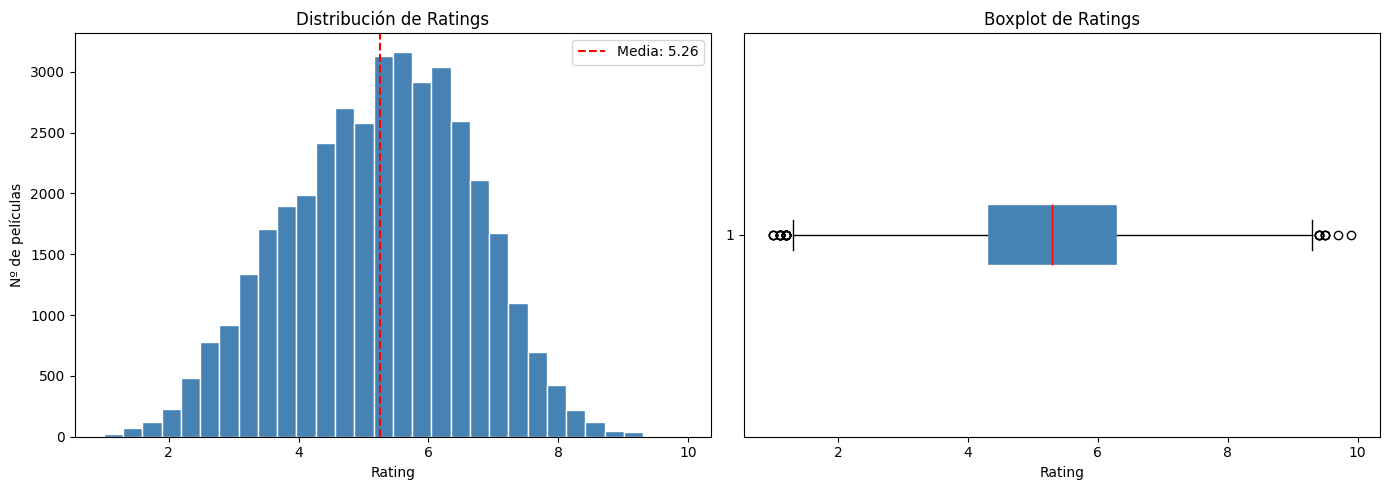


Media:    5.26
Mediana:  5.30
Std:      1.41
Mín:      1.00
Máx:      9.90


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_main['averageRating'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Nº de películas')
axes[0].axvline(df_main['averageRating'].mean(), color='red', linestyle='--', label=f'Media: {df_main["averageRating"].mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_main['averageRating'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='white'),
                medianprops=dict(color='red'))
axes[1].set_title('Boxplot de Ratings')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

print(f'\nMedia:    {df_main["averageRating"].mean():.2f}')
print(f'Mediana:  {df_main["averageRating"].median():.2f}')
print(f'Std:      {df_main["averageRating"].std():.2f}')
print(f'Mín:      {df_main["averageRating"].min():.2f}')
print(f'Máx:      {df_main["averageRating"].max():.2f}')

### 📌 Conclusiones
- Distribución **ligeramente asimétrica a la derecha** — la mayoría de películas se concentran entre 4 y 7.
- Media de **5.26** — las películas frikis tienen una valoración media moderada.
- El boxplot muestra outliers en ambos extremos — películas muy malas (< 2) y muy buenas (> 8.5).
- El rango intercuartílico va de 4.3 a 6.3 — el 50% central de las películas está en ese rango.

## 📈 Películas por año

Analizamos cómo ha evolucionado la producción de cine friki desde 1980 hasta 2026.

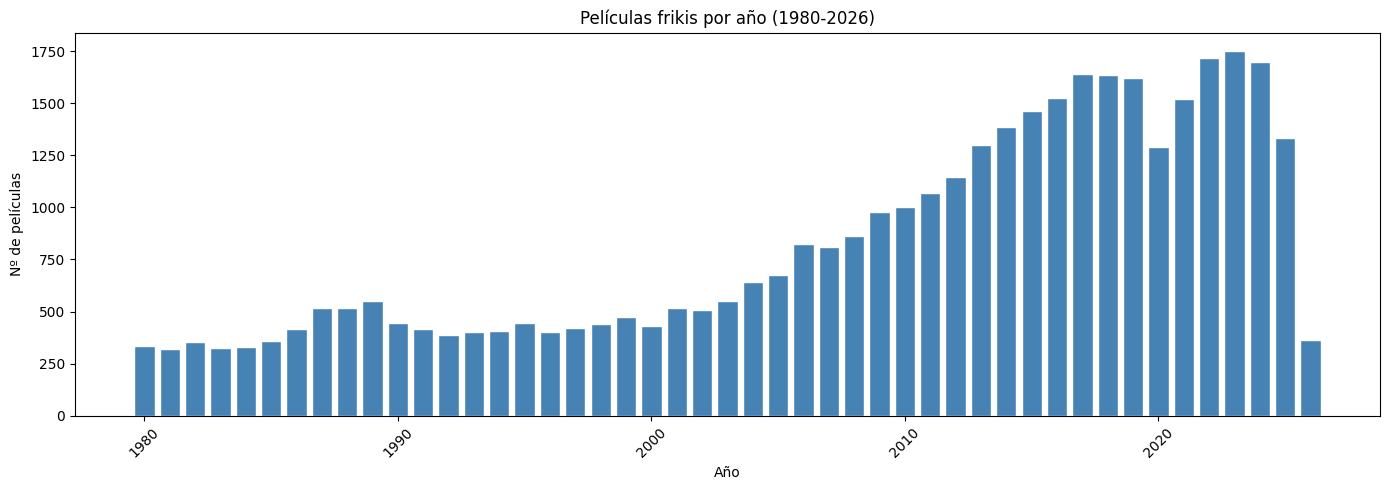

In [39]:
peliculas_año = df_main.groupby('startYear').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(peliculas_año['startYear'], peliculas_año['count'], color='steelblue', edgecolor='white')
ax.set_title('Películas frikis por año (1980-2026)')
ax.set_xlabel('Año')
ax.set_ylabel('Nº de películas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Conclusiones
- Crecimiento muy claro del cine friki desde los 2000 — la producción se **triplicó** entre 1990 y 2020.
- Los 80 y 90 se mantienen estables en torno a 300-500 películas anuales.
- El pico está en **2024-2025** con ~1.750 películas — máximo histórico.
- La caída de 2026 es esperable — el año no ha terminado y muchas películas aún no están registradas.

## 🎭 Películas por género

Analizamos qué géneros frikis tienen más representación en el dataset.

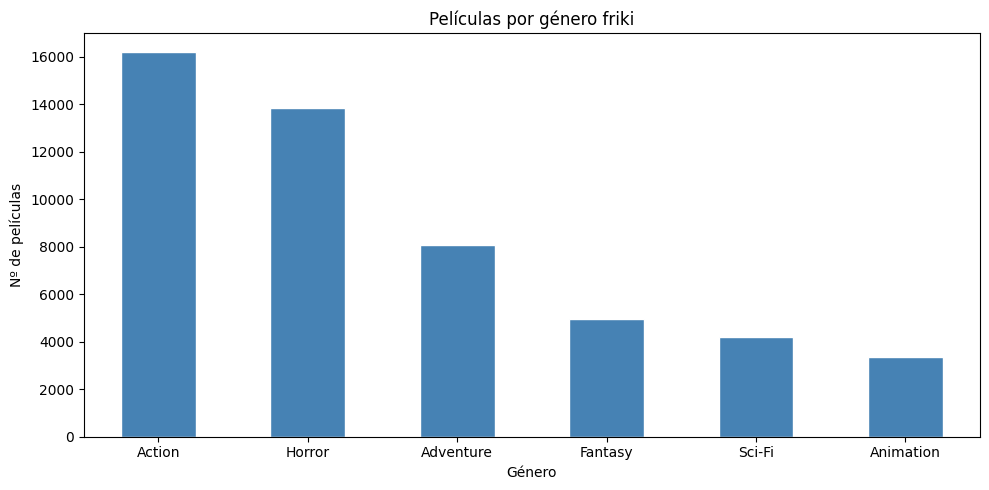

genres
Action       16197
Horror       13839
Adventure     8079
Fantasy       4960
Sci-Fi        4208
Animation     3374
Name: count, dtype: int64


In [40]:
generos_exp = df_main['genres'].str.split(',').explode().str.strip()
generos_friki = ['Action', 'Adventure', 'Animation', 'Fantasy', 'Horror', 'Sci-Fi']
generos_exp = generos_exp[generos_exp.isin(generos_friki)]

conteo = generos_exp.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Películas por género friki')
ax.set_xlabel('Género')
ax.set_ylabel('Nº de películas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(conteo)

### 📌 Conclusiones
- **Action** es el género más representado con 16.197 películas, seguido de **Horror** con 13.839.
- Una película puede pertenecer a varios géneros a la vez — los totales superan las 38.531 películas.
- **Animation** es el género menos representado con 3.374 películas — tiene sentido, es más costoso de producir.
- **Sci-Fi** sorprende con solo 4.208 películas pese a ser el género más icónico del cine friki.
- La diferencia entre Action (16k) y Animation (3k) es enorme — casi 5 veces más películas de acción.

## 🔥 Heatmap de correlaciones

Analizamos qué variables numéricas se relacionan entre sí.

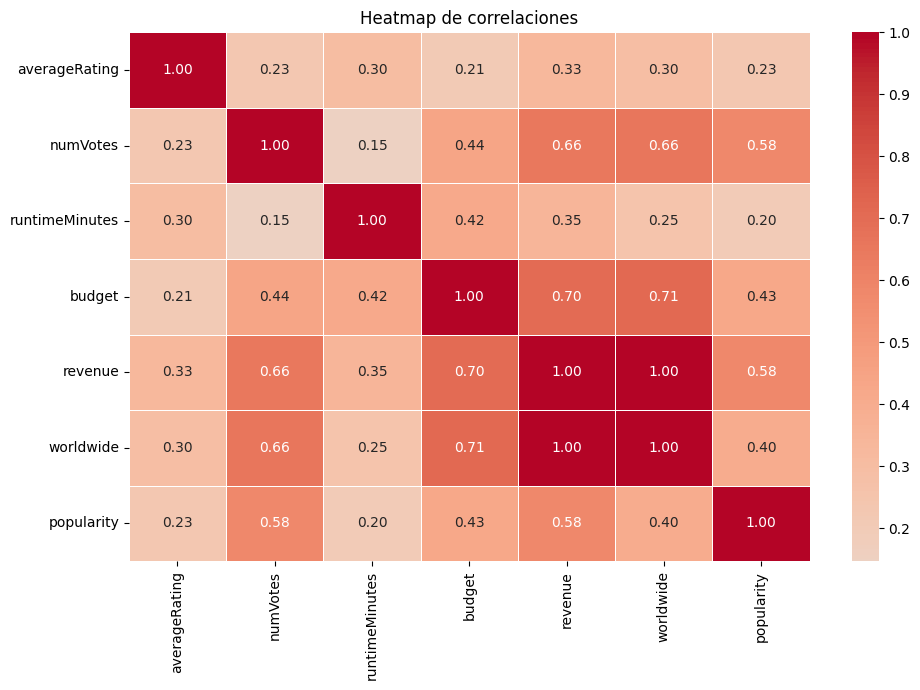

In [41]:
cols_numericas = ['averageRating', 'numVotes', 'runtimeMinutes', 'budget', 'revenue', 'worldwide', 'popularity']

corr = df_main[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap de correlaciones')
plt.tight_layout()
plt.show()

### 📌 Conclusiones
- `revenue` y `worldwide` tienen correlación de **1.00** — son prácticamente la misma variable, podemos usar solo una en Power BI.
- `budget` y `revenue` tienen correlación de **0.70** — más presupuesto tiende a generar más taquilla, pero no siempre.
- `numVotes` y `revenue` tienen correlación de **0.66** — las películas más taquilleras también son las más votadas en IMDb.
- `averageRating` tiene correlaciones bajas con todo — una película puede ser muy taquillera y mal valorada o viceversa.
- `runtimeMinutes` tiene correlación moderada con `budget` (0.42) — las películas más largas suelen tener más presupuesto.
- `popularity` correlaciona bien con `numVotes` (0.58) — las películas populares acumulan más votos.

## 💰 Budget vs Revenue

Analizamos la relación entre presupuesto y recaudación en las películas con datos económicos.

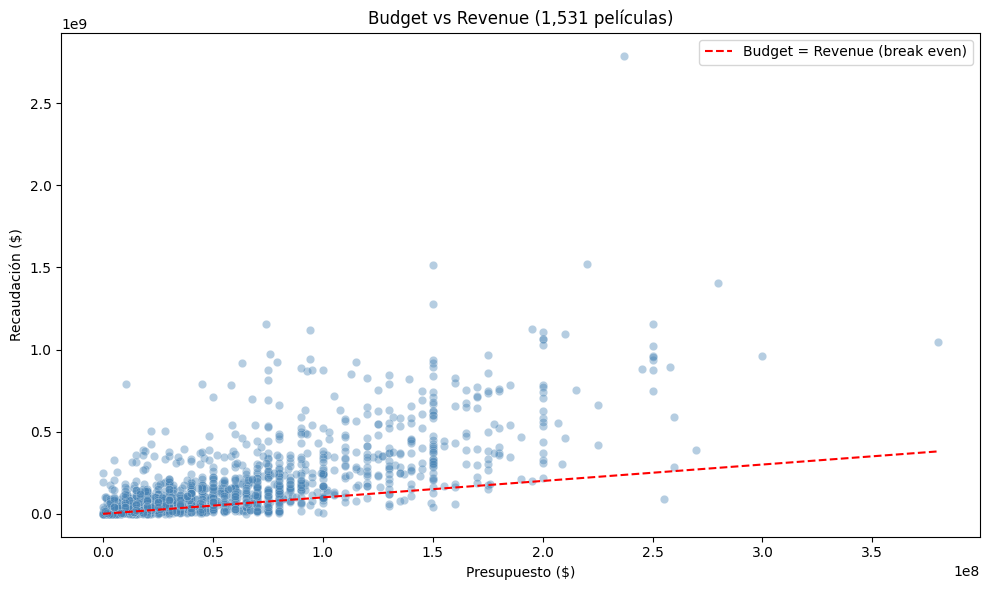

Películas con beneficio (revenue > budget): 1,189
Películas con pérdidas (revenue < budget):  342
ROI medio: 66730.8%


In [42]:
df_eco = df_main[(df_main['budget'].notna()) & (df_main['revenue'].notna())].copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_eco['budget'], df_eco['revenue'], alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.3)
ax.plot([0, df_eco['budget'].max()], [0, df_eco['budget'].max()], 'r--', label='Budget = Revenue (break even)')
ax.set_title(f'Budget vs Revenue ({len(df_eco):,} películas)')
ax.set_xlabel('Presupuesto ($)')
ax.set_ylabel('Recaudación ($)')
ax.legend()
plt.tight_layout()
plt.show()

roi = ((df_eco['revenue'] - df_eco['budget']) / df_eco['budget'] * 100)
print(f'Películas con beneficio (revenue > budget): {(df_eco["revenue"] > df_eco["budget"]).sum():,}')
print(f'Películas con pérdidas (revenue < budget):  {(df_eco["revenue"] < df_eco["budget"]).sum():,}')
print(f'ROI medio: {roi.mean():.1f}%')

### 📌 Conclusiones
- De 1.531 películas con datos económicos, **1.189 tienen beneficio (78%)** y solo 342 pérdidas (22%).
- El ROI medio de 66.730% está completamente distorsionado por outliers como Avatar — no es representativo.
- La mayoría de puntos están por encima de la línea roja — el cine friki tiende a ser rentable.
- Hay varios outliers extremos en recaudación con presupuestos medios — películas que superaron todas las expectativas.
- La nube de puntos está muy concentrada en presupuestos bajos (< 50M$) — la mayoría son producciones modestas.

## ⏱️ Distribución de duración

Analizamos cuánto duran las películas frikis.

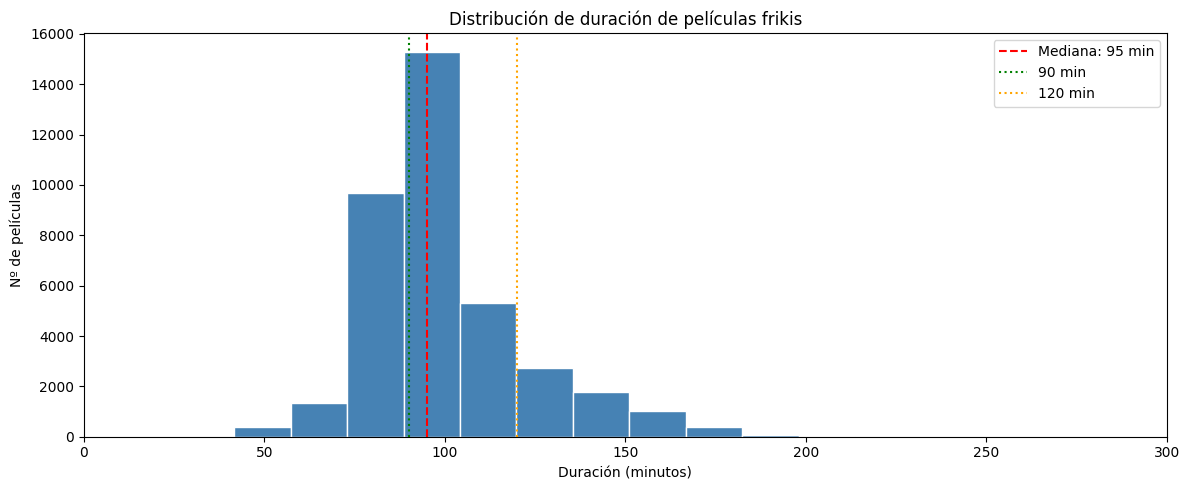

Mediana: 95 min
Media:   100 min
< 90 min:       12,314 películas
90-120 min:     20,030 películas
> 120 min:      5,650 películas


In [43]:
df_runtime = df_main[df_main['runtimeMinutes'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_runtime['runtimeMinutes'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribución de duración de películas frikis')
ax.set_xlabel('Duración (minutos)')
ax.set_ylabel('Nº de películas')
ax.axvline(df_runtime['runtimeMinutes'].median(), color='red', linestyle='--', label=f'Mediana: {df_runtime["runtimeMinutes"].median():.0f} min')
ax.axvline(90,  color='green', linestyle=':', label='90 min')
ax.axvline(120, color='orange', linestyle=':', label='120 min')
ax.set_xlim(0, 300)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mediana: {df_runtime["runtimeMinutes"].median():.0f} min')
print(f'Media:   {df_runtime["runtimeMinutes"].mean():.0f} min')
print(f'< 90 min:       {(df_runtime["runtimeMinutes"] < 90).sum():,} películas')
print(f'90-120 min:     {((df_runtime["runtimeMinutes"] >= 90) & (df_runtime["runtimeMinutes"] <= 120)).sum():,} películas')
print(f'> 120 min:      {(df_runtime["runtimeMinutes"] > 120).sum():,} películas')

### 📌 Conclusiones
- La duración mediana es **95 minutos** y la media 100 minutos — las películas frikis son relativamente cortas.
- El **52% de las películas dura entre 90 y 120 minutos** — el rango estándar de Hollywood.
- Un 32% dura menos de 90 minutos — producciones más modestas o de bajo presupuesto.
- Solo el 15% supera las 2 horas — las grandes producciones blockbuster.
- La distribución es asimétrica a la derecha — hay una cola larga de películas muy largas.

## 🌍 Top países productores de cine friki

Analizamos qué países producen más películas de nuestros géneros de interés.

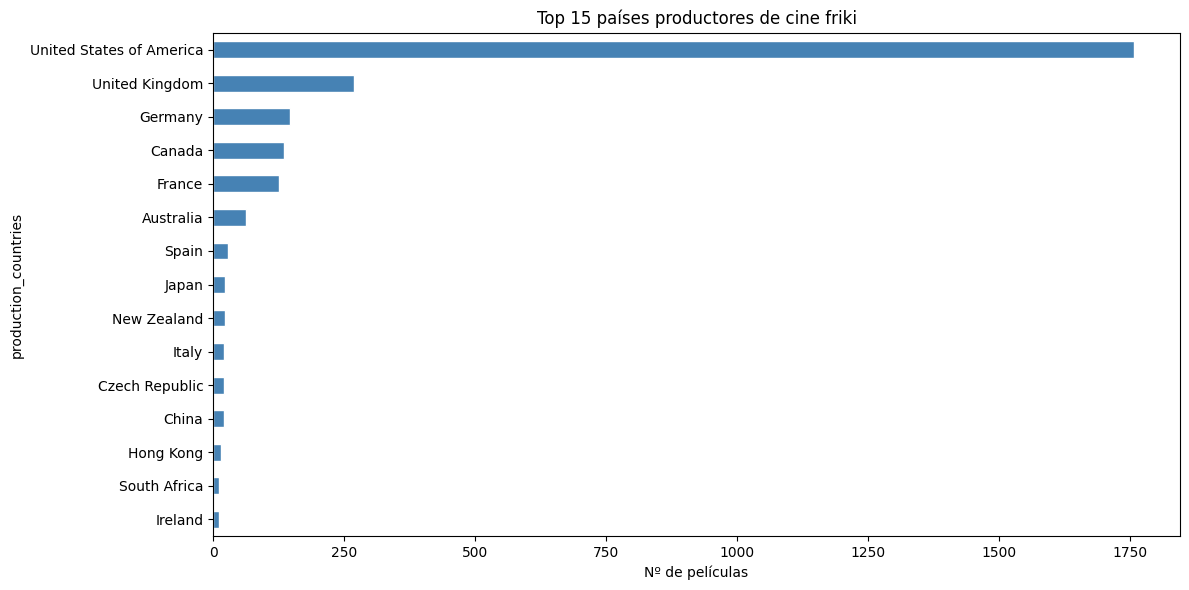

production_countries
United States of America    1757
United Kingdom               268
Germany                      146
Canada                       136
France                       125
Australia                     63
Spain                         29
Japan                         23
New Zealand                   23
Italy                         21
Czech Republic                20
China                         20
Hong Kong                     16
South Africa                  12
Ireland                       11
Name: count, dtype: int64


In [44]:
paises = df_main['production_countries'].dropna().apply(
    lambda x: x if isinstance(x, list) else ast.literal_eval(x)
).explode()

top_paises = paises.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_paises.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 países productores de cine friki')
ax.set_xlabel('Nº de películas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(top_paises)

### 📌 Conclusiones
- **USA domina completamente** con 1.757 películas — 6 veces más que el segundo país.
- UK es el segundo productor con 268 películas — muy por detrás de USA.
- Alemania, Canadá y Francia forman un grupo intermedio con 125-146 películas cada uno.
- **España aparece en el top 15** con 29 películas — pequeña pero presente. 🇪🇸
- **Japón sorprende con solo 23** películas dado que es la cuna del anime — recordemos que estos datos son solo del cruce con tmdb_movies (5% de cobertura).
- Los datos de países tienen solo un 5% de cobertura — estos resultados son orientativos, no definitivos.

## ⭐ Top directores de cine friki

Analizamos qué directores tienen más películas frikis en el dataset.

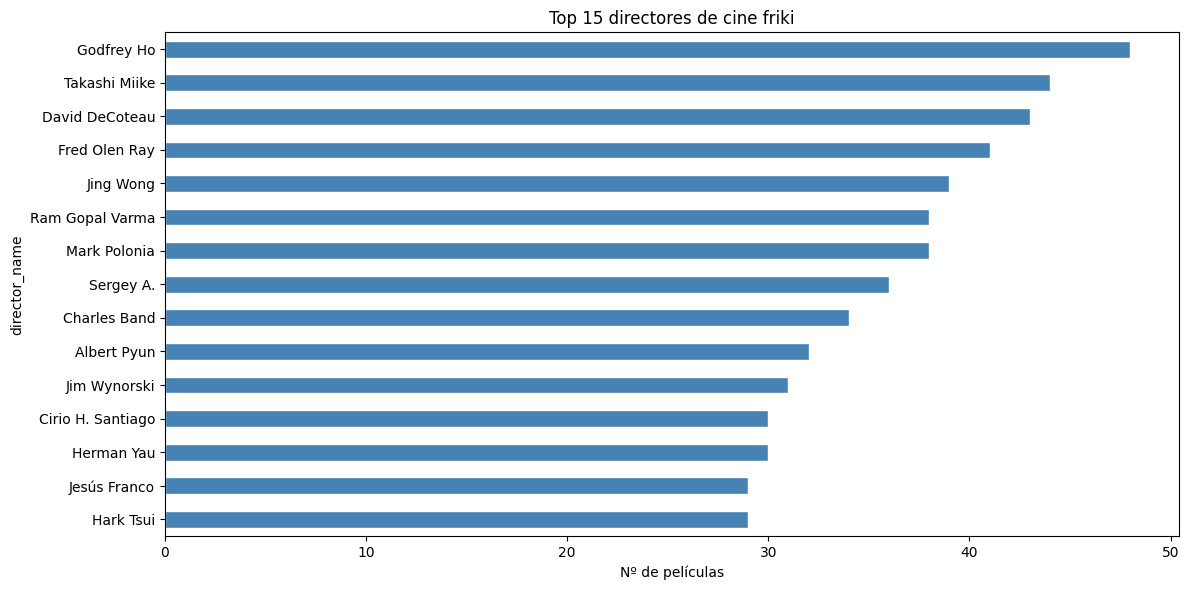

director_name
Godfrey Ho           48
Takashi Miike        44
David DeCoteau       43
Fred Olen Ray        41
Jing Wong            39
Ram Gopal Varma      38
Mark Polonia         38
Sergey A.            36
Charles Band         34
Albert Pyun          32
Jim Wynorski         31
Cirio H. Santiago    30
Herman Yau           30
Jesús Franco         29
Hark Tsui            29
Name: count, dtype: int64


In [45]:
top_directores = df_main['director_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_directores.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 directores de cine friki')
ax.set_xlabel('Nº de películas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(top_directores)

### 📌 Conclusiones
- **Godfrey Ho** lidera con 48 películas — es conocido por producir películas de artes marciales de serie B en los 80-90.
- **Takashi Miike** (44) es el único director de renombre internacional en el top — conocido por su prolífica carrera en Japón.
- El top está dominado por directores de **serie B y cine de explotación** — no aparecen directores como Spielberg o Nolan porque hacen menos películas pero más grandes.
- **Jesús Franco** en el top 15 — director español de culto especializado en terror y ciencia ficción. 🇪🇸
- Este ranking mide **cantidad**, no calidad — para ver los mejores directores por rating necesitaríamos otro análisis.

## ⭐ Top directores por rating medio

Analizamos qué directores tienen mejor valoración media (mínimo 5 películas).

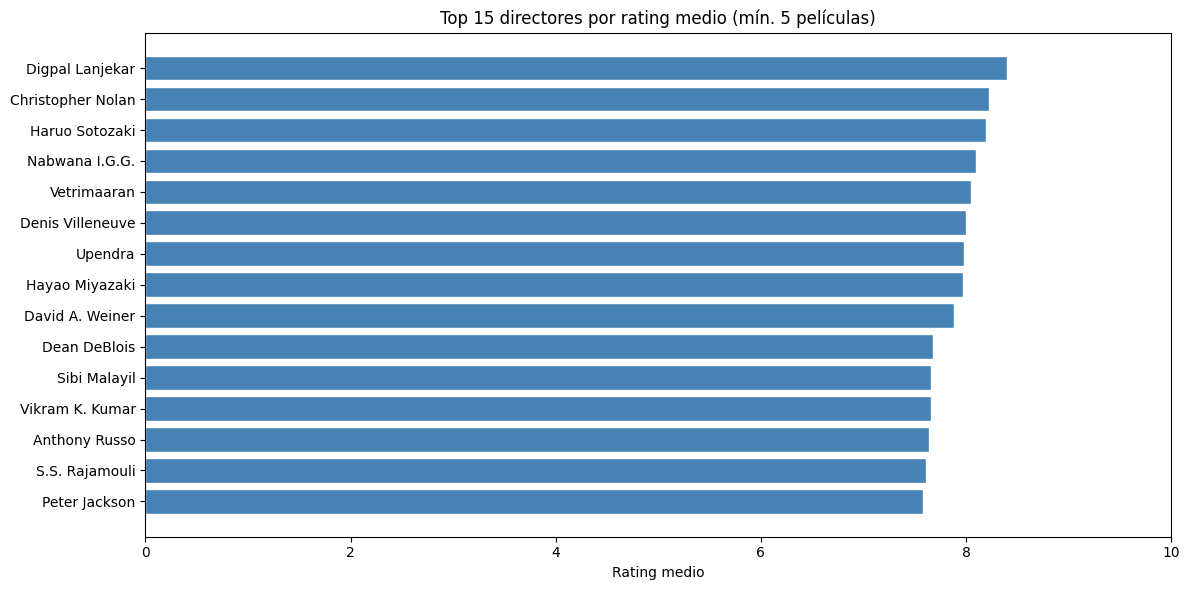

                   num_peliculas  rating_medio  votos_totales
director_name                                                
Digpal Lanjekar                5          8.40        15668.0
Christopher Nolan              5          8.22      8468226.0
Haruo Sotozaki                 8          8.19       269387.0
Nabwana I.G.G.                 5          8.10        14164.0
Vetrimaaran                    6          8.05       103277.0
Denis Villeneuve               5          8.00      3993707.0
Upendra                        5          7.98        21123.0
Hayao Miyazaki                12          7.97      3551943.0
David A. Weiner                6          7.88         9526.0
Dean DeBlois                   5          7.68      1862235.0
Sibi Malayil                   5          7.66        13707.0
Vikram K. Kumar                5          7.66        60338.0
Anthony Russo                  5          7.64      4825772.0
S.S. Rajamouli                13          7.61       600188.0
Peter Ja

In [46]:
top_rating_dir = (df_main.groupby('director_name')
                  .agg(num_peliculas=('tconst', 'count'),
                       rating_medio=('averageRating', 'mean'),
                       votos_totales=('numVotes', 'sum'))
                  .query('num_peliculas >= 5')
                  .sort_values('rating_medio', ascending=False)
                  .head(15)
                  .round(2))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_rating_dir.index, top_rating_dir['rating_medio'], color='steelblue', edgecolor='white')
ax.set_title('Top 15 directores por rating medio (mín. 5 películas)')
ax.set_xlabel('Rating medio')
ax.invert_yaxis()
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

print(top_rating_dir)

### 📌 Conclusiones
- **Christopher Nolan** (8.22) y **Denis Villeneuve** (8.00) son los directores occidentales mejor valorados — referentes del cine friki de calidad.
- **Hayao Miyazaki** (7.97) es el único director de animación en el top — con 12 películas y 3,5M votos totales, es un peso pesado.
- **Peter Jackson** (7.58) con 12 películas y 9,6M votos — el más votado del top, gracias al Señor de los Anillos.
- **Anthony Russo** (7.64) representa el cine de superhéroes Marvel con solo 5 películas pero 4,8M votos.
- **S.S. Rajamouli** (7.61) con 13 películas — el cine indio de acción tiene una presencia notable.
- Digpal Lanjekar lidera en rating (8.40) pero con solo 15.668 votos — menos representativo que Nolan o Jackson.

## 🎭 Rating medio por género

Analizamos qué géneros tienen mejor valoración media entre los usuarios de IMDb.

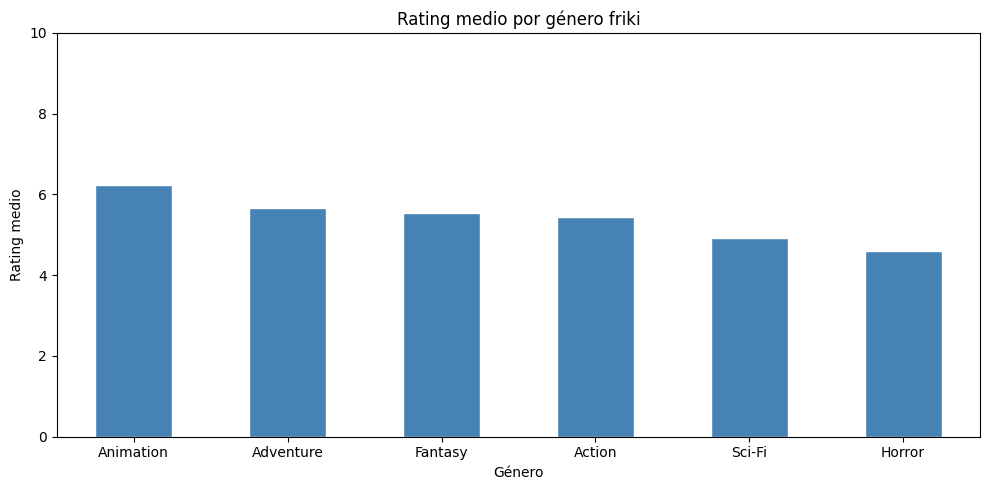

genres
Animation    6.24
Adventure    5.66
Fantasy      5.53
Action       5.45
Sci-Fi       4.91
Horror       4.61
Name: averageRating, dtype: float64


In [48]:
generos_rating = df_main.copy()
generos_rating['genres'] = generos_rating['genres'].str.split(',')
generos_rating = generos_rating.explode('genres')
generos_rating['genres'] = generos_rating['genres'].str.strip()
generos_rating = generos_rating[generos_rating['genres'].isin(['Action', 'Adventure', 'Animation', 'Fantasy', 'Horror', 'Sci-Fi'])]

rating_genero = generos_rating.groupby('genres')['averageRating'].mean().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
rating_genero.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Rating medio por género friki')
ax.set_xlabel('Género')
ax.set_ylabel('Rating medio')
ax.set_ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(rating_genero)

### 📌 Conclusiones
- **Animation es el género mejor valorado** con 6.24 de media — menos películas pero más cuidadas.
- **Horror es el peor valorado** con 4.61 — es el género con más películas de serie B y bajo presupuesto.
- La diferencia entre el mejor (Animation 6.24) y el peor (Horror 4.61) es de 1.63 puntos — significativa.
- Sci-Fi (4.91) sorprende negativamente — muchas producciones de bajo presupuesto lastran la media.
- Action (5.45) y Fantasy (5.53) se mantienen en valores medios — géneros equilibrados en calidad.

## 📈 Evolución del rating medio por año

Analizamos si la calidad del cine friki ha mejorado o empeorado con el tiempo.

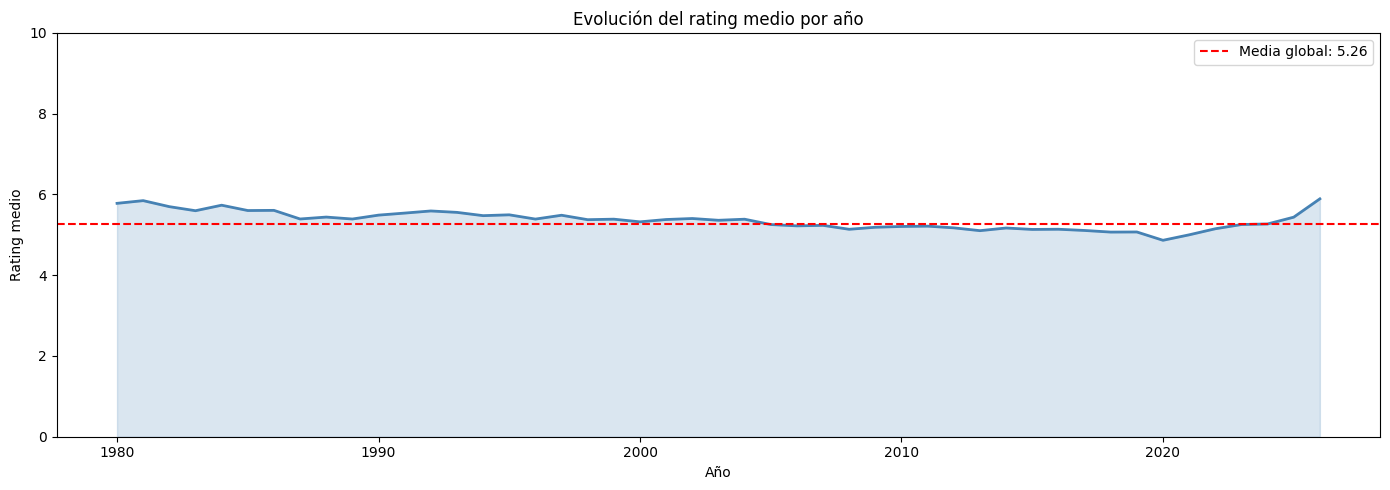

In [49]:
rating_año = df_main.groupby('startYear')['averageRating'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rating_año['startYear'], rating_año['averageRating'], color='steelblue', linewidth=2)
ax.fill_between(rating_año['startYear'], rating_año['averageRating'], alpha=0.2, color='steelblue')
ax.set_title('Evolución del rating medio por año')
ax.set_xlabel('Año')
ax.set_ylabel('Rating medio')
ax.set_ylim(0, 10)
ax.axhline(df_main['averageRating'].mean(), color='red', linestyle='--', label=f'Media global: {df_main["averageRating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

### 📌 Conclusiones
- El rating medio se ha mantenido **muy estable** entre 5.0 y 6.0 durante toda la historia.
- Los **años 80 tienen ratings ligeramente más altos** (~5.8) — posiblemente porque solo las películas más conocidas tienen votos suficientes para estar en el dataset.
- Hay una **caída suave desde 1980 hasta 2010** — la masificación de la producción baja la media.
- El **mínimo se da alrededor de 2020** (~4.9) — coincide con el boom de producciones de streaming de baja calidad.
- La **subida en 2025-2026** es por sesgo — las películas recientes con pocos votos tienden a tener ratings más extremos.

## 🏆 Top 10 películas mejor valoradas

Las 10 películas frikis mejor valoradas del dataset con más de 10.000 votos.

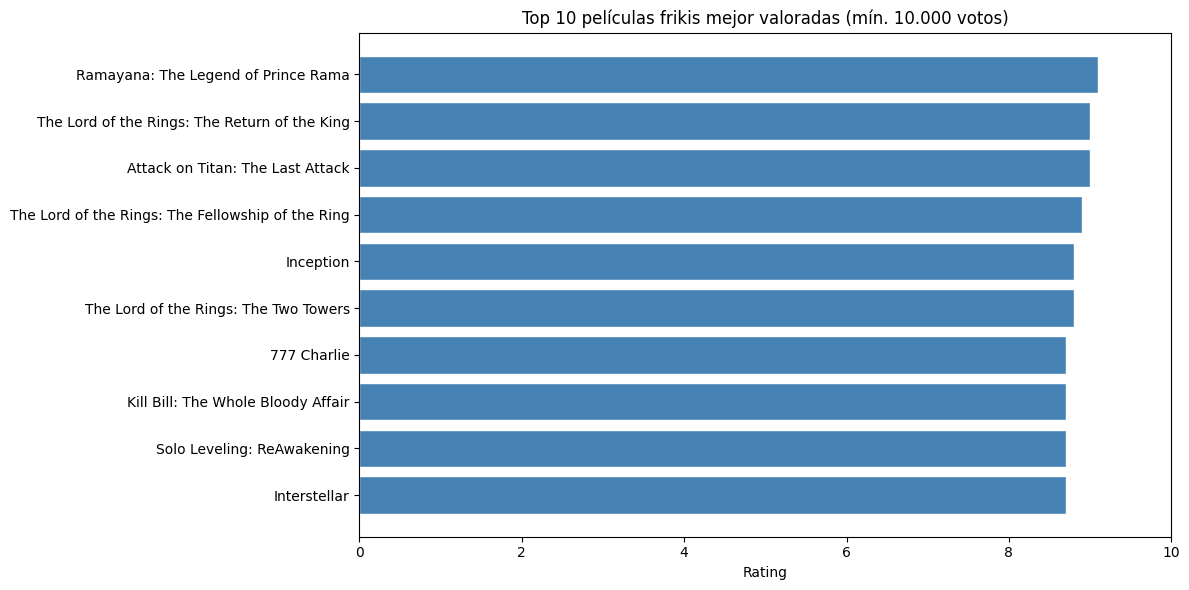

,primaryTitle,startYear,genres,averageRating,numVotes,director_name
8151,Ramayana: The Legend of Prince Rama,1993,"Action,Adventure,Animation",9.1,17801.0,Ram Mohan
6634,The Lord of the Rings: The Return of the King,2003,"Adventure,Drama,Fantasy",9.0,2170446.0,Peter Jackson
29729,Attack on Titan: The Last Attack,2024,"Action,Adventure,Animation",9.0,31130.0,Ryota Aikei
5722,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure,Drama,Fantasy",8.9,2212653.0,Peter Jackson
18054,Inception,2010,"Adventure,Sci-Fi,Thriller",8.8,2827344.0,Christopher Nolan
6635,The Lord of the Rings: The Two Towers,2002,"Adventure,Drama,Fantasy",8.8,1962624.0,Peter Jackson
37123,777 Charlie,2022,"Adventure,Comedy,Drama",8.7,47868.0,Kiranraj K
35268,Kill Bill: The Whole Bloody Affair,2004,"Action,Crime,Thriller",8.7,44852.0,Quentin Tarantino
29896,Solo Leveling: ReAwakening,2024,"Action,Adventure,Animation",8.7,17302.0,Shunsuke Nakashige
12713,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.7,2547001.0,Christopher Nolan


In [50]:
top10 = (df_main[df_main['numVotes'] >= 10000]
         .sort_values('averageRating', ascending=False)
         .head(10)[['primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes', 'director_name']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10['primaryTitle'], top10['averageRating'], color='steelblue', edgecolor='white')
ax.set_title('Top 10 películas frikis mejor valoradas (mín. 10.000 votos)')
ax.set_xlabel('Rating')
ax.set_xlim(0, 10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(top10)

### 📌 Conclusiones
- **El Señor de los Anillos domina el top** con las 3 películas de la trilogía de Peter Jackson.
- **Inception e Interstellar** de Christopher Nolan confirman su posición como el mejor director del dataset.
- **Ramayana: The Legend of Prince Rama** lidera con 9.0 — película de animación india de 1992, muy valorada por su comunidad.
- **Attack on Titan: The Last Attack** y **Solo Leveling: ReAwakening** — el anime tiene una presencia fuerte en el top.
- **Kill Bill: The Whole Bloody Cut** — versión extendida de Tarantino, clásico de culto. ✅
- El top mezcla géneros: Fantasy (LOTR), Sci-Fi (Nolan), Animation (anime) — el cine friki de calidad es diverso.

## ⏱️ Duración media por género

Analizamos si hay diferencias significativas en la duración según el género.

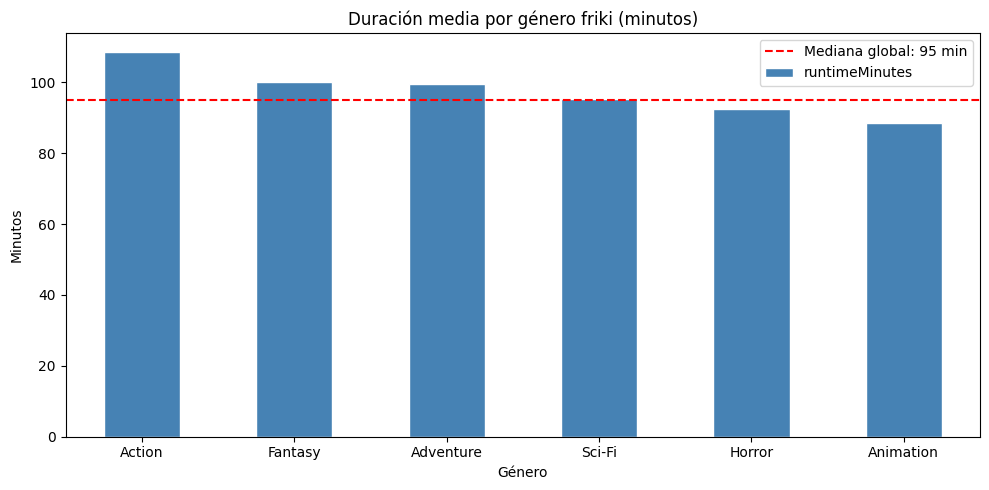

genres
Action       108.5
Fantasy      100.0
Adventure     99.4
Sci-Fi        95.3
Horror        92.4
Animation     88.5
Name: runtimeMinutes, dtype: Float64


In [51]:
duracion_genero = (df_main[df_main['runtimeMinutes'].notna()].copy())
duracion_genero['genres'] = duracion_genero['genres'].str.split(',')
duracion_genero = duracion_genero.explode('genres')
duracion_genero['genres'] = duracion_genero['genres'].str.strip()
duracion_genero = duracion_genero[duracion_genero['genres'].isin(['Action', 'Adventure', 'Animation', 'Fantasy', 'Horror', 'Sci-Fi'])]

dur_media = duracion_genero.groupby('genres')['runtimeMinutes'].mean().sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
dur_media.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Duración media por género friki (minutos)')
ax.set_xlabel('Género')
ax.set_ylabel('Minutos')
ax.axhline(df_main['runtimeMinutes'].median(), color='red', linestyle='--', label=f'Mediana global: {df_main["runtimeMinutes"].median():.0f} min')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(dur_media)

### 📌 Conclusiones
- **Action es el género más largo** con 108.5 minutos de media — las películas de acción necesitan más tiempo para desarrollar sus secuencias.
- **Animation es el más corto** con 88.5 minutos — pensado para audiencias más amplias incluyendo niños.
- Todos los géneros están en un rango compacto de 88-108 minutos — no hay diferencias extremas.
- Horror (92.4) y Animation (88.5) están por debajo de la mediana global de 95 minutos.
- Action, Fantasy y Adventure superan la mediana — son géneros que requieren más desarrollo narrativo.

## 🏆 Top 10 películas más votadas

Las películas con más votos en IMDb — las más vistas y comentadas por los usuarios.

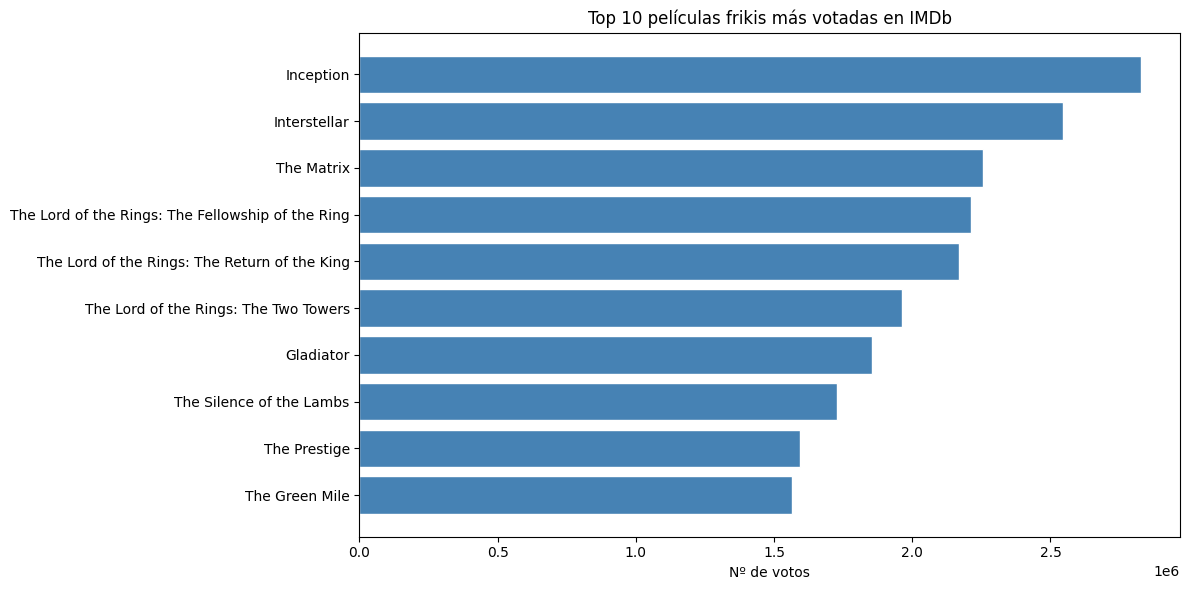

,primaryTitle,startYear,genres,averageRating,numVotes,director_name
18054,Inception,2010,"Adventure,Sci-Fi,Thriller",8.8,2827344.0,Christopher Nolan
12713,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.7,2547001.0,Christopher Nolan
6034,The Matrix,1999,"Action,Sci-Fi",8.7,2254915.0,Lana Wachowski
5722,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure,Drama,Fantasy",8.9,2212653.0,Peter Jackson
6634,The Lord of the Rings: The Return of the King,2003,"Adventure,Drama,Fantasy",9.0,2170446.0,Peter Jackson
6635,The Lord of the Rings: The Two Towers,2002,"Adventure,Drama,Fantasy",8.8,1962624.0,Peter Jackson
6712,Gladiator,2000,"Action,Adventure,Drama",8.5,1856084.0,Ridley Scott
3635,The Silence of the Lambs,1991,"Crime,Drama,Horror",8.6,1728689.0,Jonathan Demme
12084,The Prestige,2006,"Drama,Mystery,Sci-Fi",8.5,1594835.0,Christopher Nolan
5714,The Green Mile,1999,"Crime,Drama,Fantasy",8.6,1566086.0,Frank Darabont


In [52]:
top10_votos = (df_main.sort_values('numVotes', ascending=False)
               .head(10)[['primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes', 'director_name']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10_votos['primaryTitle'], top10_votos['numVotes'], color='steelblue', edgecolor='white')
ax.set_title('Top 10 películas frikis más votadas en IMDb')
ax.set_xlabel('Nº de votos')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(top10_votos)

### 📌 Conclusiones
- **Inception lidera** con 2,8M votos — la película friki más comentada de IMDb.
- **Christopher Nolan tiene 3 películas en el top 10** (Inception, Interstellar, The Prestige) — el director más popular del dataset.
- **Peter Jackson también tiene 3** (toda la trilogía LOTR) — confirma su dominio en el top.
- El top 10 más votado y el top 10 mejor valorado se solapan bastante — las películas muy vistas también tienden a ser muy valoradas.
- **The Matrix** (Wachowski) y **Gladiator** (Ridley Scott) representan el cine de acción de culto de los 2000.
- **The Silence of the Lambs** es la única película de Horror en el top — terror de calidad con 1,7M votos.
- **The Green Mile** — un clásico imprescindible. 🟢

## 💀 Bottom 10 películas peor valoradas

Las 10 películas frikis peor valoradas con más de 10.000 votos — las más odiadas por los usuarios.

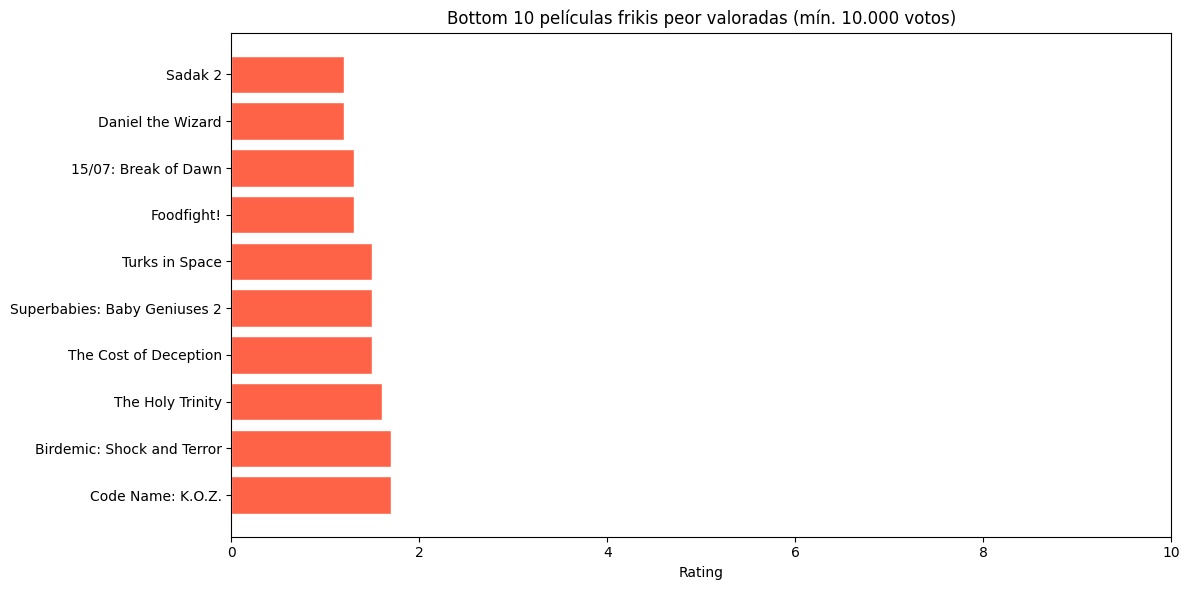

,primaryTitle,startYear,genres,averageRating,numVotes,director_name
37576,Sadak 2,2020,"Action,Drama",1.2,97207.0,Mahesh Bhatt
11000,Daniel the Wizard,2004,"Comedy,Crime,Fantasy",1.2,15178.0,Ulli Lommel
19247,15/07: Break of Dawn,2021,"Action,Drama,War",1.3,20700.0,Volkan Kocatürk
7981,Foodfight!,2012,"Adventure,Animation,Comedy",1.3,12688.0,Lawrence Kasanoff
12627,Turks in Space,2006,"Action,Comedy,Sci-Fi",1.5,17022.0,Kartal Tibet
8354,Superbabies: Baby Geniuses 2,2003,"Comedy,Family,Sci-Fi",1.5,32112.0,Bob Clark
19094,The Cost of Deception,2021,"Action,Crime,Drama",1.5,40926.0,Keith English
19711,The Holy Trinity,2023,Horror,1.6,12372.0,Shalom Kolontarov
17391,Birdemic: Shock and Terror,2010,"Horror,Thriller",1.7,27132.0,James Nguyen
32799,Code Name: K.O.Z.,2015,"Action,Crime,Mystery",1.7,27574.0,Celal Çimen


In [53]:
bottom10 = (df_main[df_main['numVotes'] >= 10000]
            .sort_values('averageRating', ascending=True)
            .head(10)[['primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes', 'director_name']])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(bottom10['primaryTitle'], bottom10['averageRating'], color='tomato', edgecolor='white')
ax.set_title('Bottom 10 películas frikis peor valoradas (mín. 10.000 votos)')
ax.set_xlabel('Rating')
ax.set_xlim(0, 10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(bottom10)

### 📌 Conclusiones
- **Sadak 2 (1.2)** es la peor valorada — película india de 2020 que fue bombardeada con votos negativos por razones políticas más que cinematográficas.
- **Foodfight! (1.3)** es famosa en internet por ser una de las peores animaciones de la historia — producción caótica con 45M$ de presupuesto.
- **Superbabies: Baby Geniuses 2 (1.5)** — secuela infame que aparece en todas las listas de peores películas de la historia.
- **Birdemic (1.7)** es un clásico del cine de terror tan malo que se ha convertido en película de culto — famosa por sus efectos especiales ridículos.
- El bottom 10 está dominado por **Action y Horror** — los géneros más fáciles de producir mal.
- Todos tienen ratings entre 1.2 y 1.7 — con más de 10.000 votos cada una, hay mucha gente que las ha visto para opinar.
- Ninguna es de directores conocidos — confirma que el talento del director importa.

## 🌍 Top 10 idiomas originales

Analizamos en qué idiomas se producen más películas frikis.

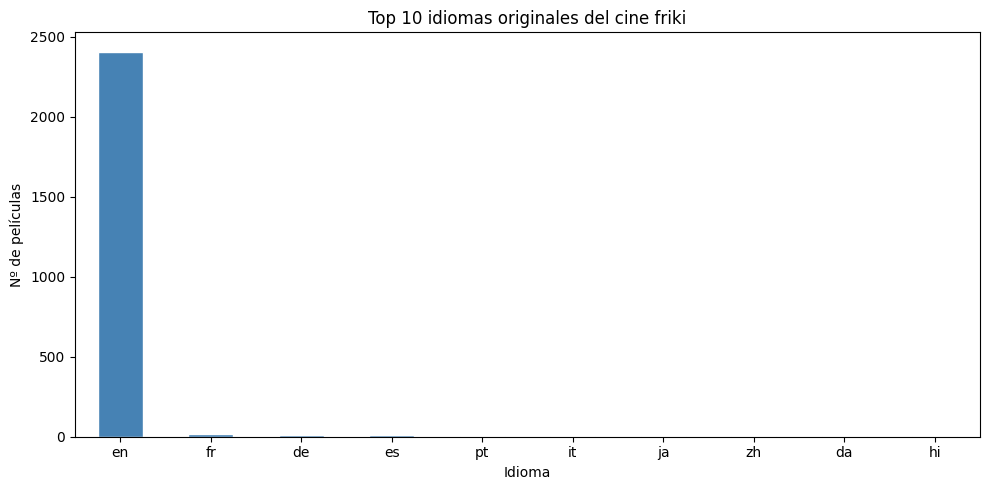

original_language
en    2408
fr      18
de      11
es       8
pt       3
it       2
ja       2
zh       2
da       2
hi       2
Name: count, dtype: int64


In [54]:
top_idiomas = df_main['original_language'] if 'original_language' in df_main.columns else None

if top_idiomas is None:
    # Buscamos en tmdb_movies
    lang = tmdb_movies[['original_title', 'original_language']].copy()
    df_lang = df_main.merge(lang, left_on='originalTitle', right_on='original_title', how='left')
    top_idiomas = df_lang['original_language'].value_counts().head(10)
else:
    top_idiomas = df_main['original_language'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_idiomas.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 idiomas originales del cine friki')
ax.set_xlabel('Idioma')
ax.set_ylabel('Nº de películas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(top_idiomas)

Películas con idioma: 5,365
Cobertura: 13.9%


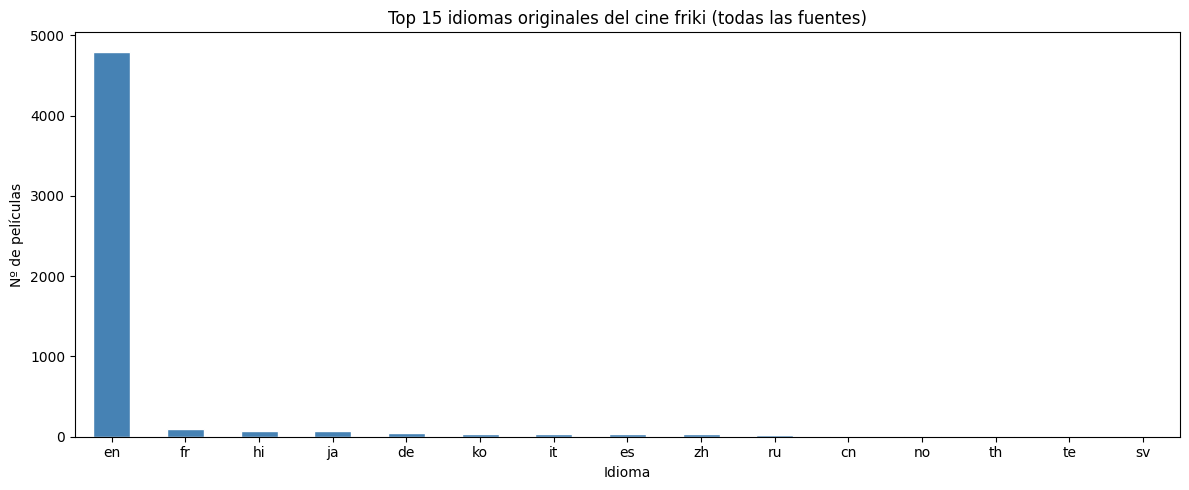

original_language
en    4796
fr      97
hi      76
ja      68
de      50
ko      37
it      34
es      34
zh      31
ru      27
cn      14
no      12
th      10
te      10
sv       9
Name: count, dtype: int64


In [55]:
# Recogemos idiomas de todas las fuentes disponibles
lang_tmdb    = tmdb_movies[['original_title', 'original_language']].rename(columns={'original_title': 'originalTitle'})
lang_extra   = tmdb_extra[['title', 'original_language']].rename(columns={'title': 'originalTitle'})
lang_box     = box_office[['title', 'original_language']].rename(columns={'title': 'originalTitle'})

# Unimos todas las fuentes
lang_all = pd.concat([lang_tmdb, lang_extra, lang_box]).drop_duplicates(subset='originalTitle')

# Cruzamos con df_main
df_lang_completo = df_main.merge(lang_all, on='originalTitle', how='left')

print(f'Películas con idioma: {df_lang_completo["original_language"].notna().sum():,}')
print(f'Cobertura: {df_lang_completo["original_language"].notna().sum()/len(df_main)*100:.1f}%')

top_idiomas_completo = df_lang_completo['original_language'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
top_idiomas_completo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 idiomas originales del cine friki (todas las fuentes)')
ax.set_xlabel('Idioma')
ax.set_ylabel('Nº de películas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(top_idiomas_completo)

### 📌 Conclusiones — versión completa
- Con todas las fuentes combinadas tenemos idioma para **4.796 películas** — mucho más representativo.
- **Inglés sigue dominando** con 4.796 películas pero la diferencia con el resto es menos extrema.
- **Francés (97) e Hindi (76)** son el segundo y tercer idioma — el cine de Bollywood tiene presencia notable.
- **Japonés (68)** sube significativamente — confirma la importancia del cine japonés en el género friki.
- **Coreano (37)** aparece con fuerza — el auge del cine coreano (Parasite, Train to Busan) se refleja en los datos.
- **Español (34)** está presente — empatado con italiano. 🇪🇸
- **Chino (31+14)** si sumamos `zh` y `cn` sería el 5º idioma con 45 películas.
- La diversidad lingüística es mucho mayor de lo que parecía con solo tmdb_movies.

## 📈 Evolución de géneros frikis por año

Analizamos cómo ha crecido cada género a lo largo del tiempo.

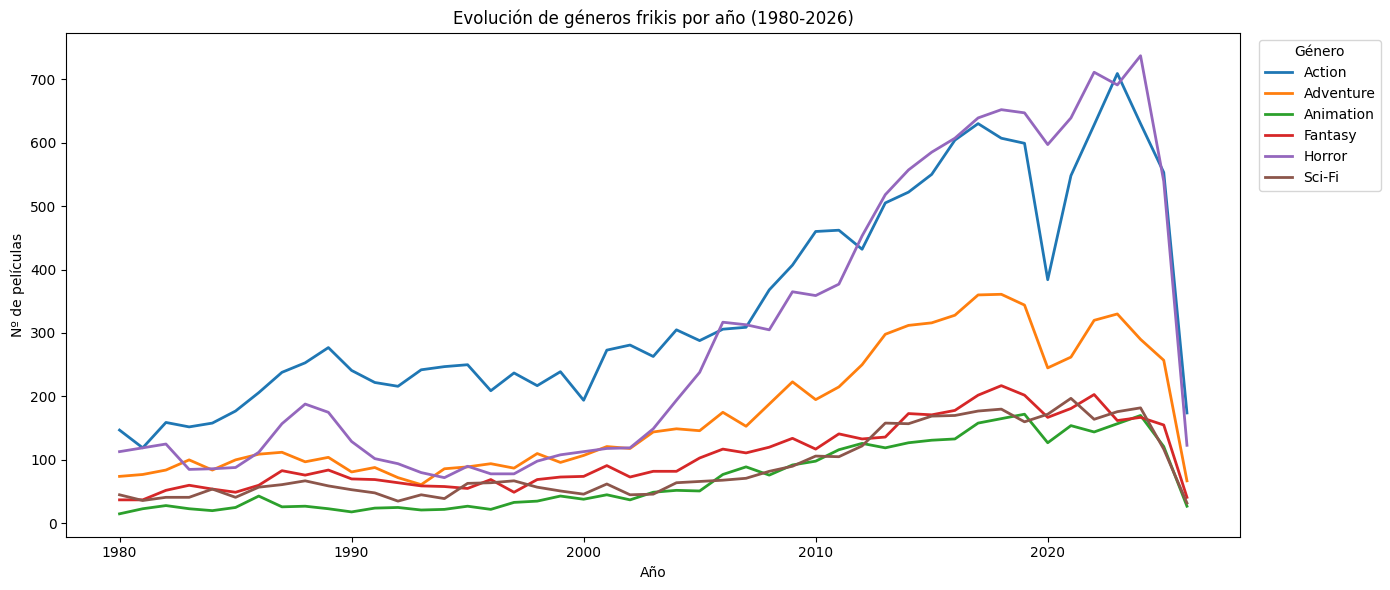

In [56]:
gen_año = df_main[['startYear', 'genres']].copy()
gen_año['genres'] = gen_año['genres'].str.split(',')
gen_año = gen_año.explode('genres')
gen_año['genres'] = gen_año['genres'].str.strip()
gen_año = gen_año[gen_año['genres'].isin(['Action', 'Adventure', 'Animation', 'Fantasy', 'Horror', 'Sci-Fi'])]

evol = gen_año.groupby(['startYear', 'genres']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
evol.plot(ax=ax, linewidth=2)
ax.set_title('Evolución de géneros frikis por año (1980-2026)')
ax.set_xlabel('Año')
ax.set_ylabel('Nº de películas')
ax.legend(title='Género', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📌 Conclusiones
- **Horror supera a Action en 2020** y se convierte en el género más producido — el boom del terror de streaming es real.
- **Action dominó desde 1980 hasta ~2018** — durante 40 años fue el rey indiscutible.
- **La caída brusca en 2026** es esperada — el año no ha terminado y faltan películas por registrarse.
- **La caída de 2020** en Action y Adventure es claramente el impacto del **COVID** — los rodajes se paralizaron.
- **Horror apenas se vio afectado por el COVID** — las producciones de bajo presupuesto se adaptaron mejor.
- **Animation, Fantasy y Sci-Fi crecen lentamente pero de forma constante** — nunca explotan pero tampoco caen.
- **Adventure despega a partir de 2010** — coincide con el auge de las franquicias Marvel y DC.
- El crecimiento general desde 2000 es exponencial en todos los géneros — la democratización del cine digital lo explica.

# 🏁 Conclusiones Finales del EDA

## 📁 Datos de partida
- Arrancamos con **9 archivos** de dos fuentes: IMDb oficial y Kaggle.
- Más de **40 millones de filas** en total entre todos los archivos.
- Tras limpieza y filtrado: **dataset final de 38.531 películas frikis**.

---

## 🧹 Proceso realizado
1. **Filtrado de IMDb** — de 12,5M títulos a 38.531 películas frikis con rating fiable y mínimo 100 votos.
2. **Limpieza individual** de cada dataset — nulos, tipos de datos, valores erróneos y columnas irrelevantes.
3. **4 cruces progresivos** para enriquecer el dataset base con datos económicos, popularidad y URLs.
4. **Eliminación de duplicados** tras cada cruce para mantener la integridad del dataset.

---

## 🎬 Sobre las películas
- El género más producido es **Horror (13.839)** y **Action (16.197)** — Horror superó a Action en 2020.
- **Animation es el género menos producido (3.374)** pero el **mejor valorado (6.24)**.
- La producción de cine friki se **triplicó entre 1990 y 2020** — crecimiento constante.
- El **COVID impactó claramente en 2020** — caída brusca en Action y Adventure pero no en Horror.
- **Adventure despega a partir de 2010** — coincide con el auge de Marvel y DC.
- El pico histórico es **2024-2025** con ~1.750 películas anuales.

---

## ⭐ Sobre los ratings
- Rating medio de **5.26 sobre 10** — distribución centrada y ligeramente asimétrica.
- El 50% de las películas tienen entre 4.3 y 6.3 de rating.
- **Animation (6.24) es el mejor valorado** y **Horror (4.61) el peor**.
- El rating se ha mantenido estable entre 5.0 y 6.0 durante toda la historia.
- **Christopher Nolan** (8.22) y **Hayao Miyazaki** (7.97) son los directores mejor valorados con filmografía amplia.
- **Inception** es la película más votada con 2,8M votos — la friki más comentada de IMDb.
- **El Señor de los Anillos: El Retorno del Rey** es la mejor valorada con 9.0 y 10.000+ votos.
- **Sadak 2 (1.2)** es la peor valorada — bombardeada con votos negativos por razones políticas.

---

## 💰 Sobre la economía
- El **78% de las películas con datos económicos tienen beneficio**.
- `revenue` y `worldwide` son prácticamente la misma variable (correlación 1.00) — usaremos solo una en Power BI.
- `budget` y `revenue` tienen correlación de 0.70 — más presupuesto tiende a más taquilla pero no siempre.
- El rating tiene correlación baja con taquilla — una película puede ser mala y recaudar mucho.
- Los datos económicos solo cubren el **5-7% del dataset** — son orientativos.

---

## 🌍 Sobre los países e idiomas
- **USA domina** la producción con 1.757 películas — 6 veces más que UK (268).
- **España aparece en el top 15** con 29 películas y 34 en idioma español. 🇪🇸
- **Inglés domina** con el 98% de las películas con dato de idioma.
- **Hindi (76) y Japonés (68)** son el 3º y 4º idioma — Bollywood y anime tienen presencia real.
- **Coreano (37)** refleja el auge del cine coreano en los últimos años.

---

## ⏱️ Sobre la duración
- Duración mediana de **95 minutos** — el cine friki es compacto.
- **Action es el género más largo (108.5 min)** y **Animation el más corto (88.5 min)**.
- El 52% de las películas dura entre 90 y 120 minutos.

---

## 🎥 Directores destacados
- **Godfrey Ho (48 películas)** es el más prolífico — cine de serie B de artes marciales.
- **Christopher Nolan, Peter Jackson y Hayao Miyazaki** dominan tanto en cantidad como en calidad.
- **Jesús Franco** en el top 15 de cantidad — director español de culto. 🇪🇸

---

## 📊 Dataset final — df_main
| Columna | Cobertura | Uso en Power BI |
|---|---|---|
| `primaryTitle`, `startYear`, `genres` | 100% | Filtros y dimensiones principales |
| `averageRating`, `numVotes` | 100% | KPIs de valoración |
| `director_name` | 99.8% | Filtro por director |
| `runtimeMinutes` | 98.6% | Análisis de duración |
| `budget`, `revenue`, `worldwide` | 5-7% | Análisis económico parcial |
| `production_countries` | 5% | Mapa de países productores |
| `popularity`, `overview` | 14-15% | Enriquecimiento complementario |

---

## 🚀 Próximos pasos
- Importar `df_main.csv` en Power BI.
- Crear tabla de géneros separada (explodear géneros para filtros).
- Construir modelo de datos en Power BI.
- Desarrollar las 4 páginas del dashboard.